In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12,6)
sns.set_style('whitegrid')

In [78]:
bike_df = pd.read_csv('/content/bike_share_cleaned_480k.csv')

In [79]:
bike_df.shape
bike_df.head()
bike_df.info()
bike_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420248 entries, 0 to 420247
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   trip_id             420248 non-null  int64  
 1   start_station_id    420248 non-null  float64
 2   start_time          420248 non-null  object 
 3   start_station_name  420248 non-null  object 
 4   end_station_id      420247 non-null  float64
 5   end_time            420247 non-null  object 
 6   end_station_name    420247 non-null  object 
 7   bike_id             420247 non-null  float64
 8   user_type           420247 non-null  object 
 9   hour                420247 non-null  float64
 10  day                 420247 non-null  object 
 11  month               420247 non-null  float64
 12  trip_duration       420247 non-null  float64
dtypes: float64(6), int64(1), object(6)
memory usage: 41.7+ MB


,trip_id,start_station_id,end_station_id,bike_id,hour,month,trip_duration
count,4.202480e+05,420248.000000,420247.000000,420247.000000,420247.000000,420247.000000,4.202470e+05
mean,2.656231e+07,7328.150987,7324.147956,4420.413531,14.474737,6.134530,9.968245e+02
std,9.217650e+06,265.493640,264.827472,2587.479675,5.068850,2.505947,4.834347e+03
min,1.480521e+07,7000.000000,7000.000000,14.000000,0.000000,1.000000,0.000000e+00
25%,1.760090e+07,7103.000000,7101.000000,2313.000000,11.000000,5.000000,4.260000e+02
50%,2.730740e+07,7268.000000,7261.000000,4395.000000,15.000000,6.000000,6.980000e+02
75%,3.616037e+07,7491.000000,7476.000000,6238.000000,18.000000,8.000000,1.125000e+03
max,4.368238e+07,8189.000000,8189.000000,10617.000000,23.000000,12.000000,1.479867e+06


In [80]:
bike_df.isnull().sum()

,0
trip_id,0
start_station_id,0
start_time,0
start_station_name,0
end_station_id,1
end_time,1
end_station_name,1
bike_id,1
user_type,1
hour,1


In [81]:
bike_df.duplicated().sum()

np.int64(93395)

In [82]:
bike_df.drop_duplicates(inplace=True)

In [83]:
bike_df['start_time'] = pd.to_datetime(
    bike_df['start_time'],
    errors='coerce'
)

bike_df['end_time'] = pd.to_datetime(
    bike_df['end_time'],
    errors='coerce'
)

In [84]:
bike_df['hour'] = bike_df['start_time'].dt.hour
bike_df['day'] = bike_df['start_time'].dt.day_name()
bike_df['month'] = bike_df['start_time'].dt.month
bike_df['year'] = bike_df['start_time'].dt.year
bike_df['weekend'] = bike_df['day'].isin(
    ['Saturday','Sunday']
).astype(int)

In [85]:
bike_df[bike_df.duplicated()].head()

,trip_id,start_station_id,start_time,start_station_name,end_station_id,end_time,end_station_name,bike_id,user_type,hour,day,month,trip_duration,year,weekend


In [86]:
duplicate_count = bike_df.duplicated().sum()

print("Current duplicate rows:", duplicate_count)
print("Current dataset shape:", bike_df.shape)

Current duplicate rows: 0
Current dataset shape: (326853, 15)


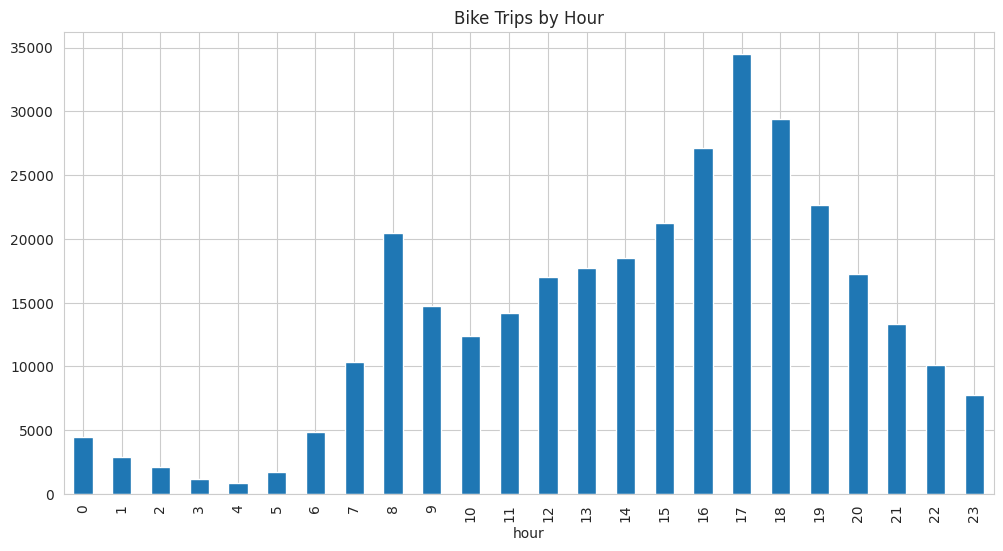

In [87]:
bike_df.groupby('hour').size().plot(kind='bar')
plt.title('Bike Trips by Hour')
plt.show()

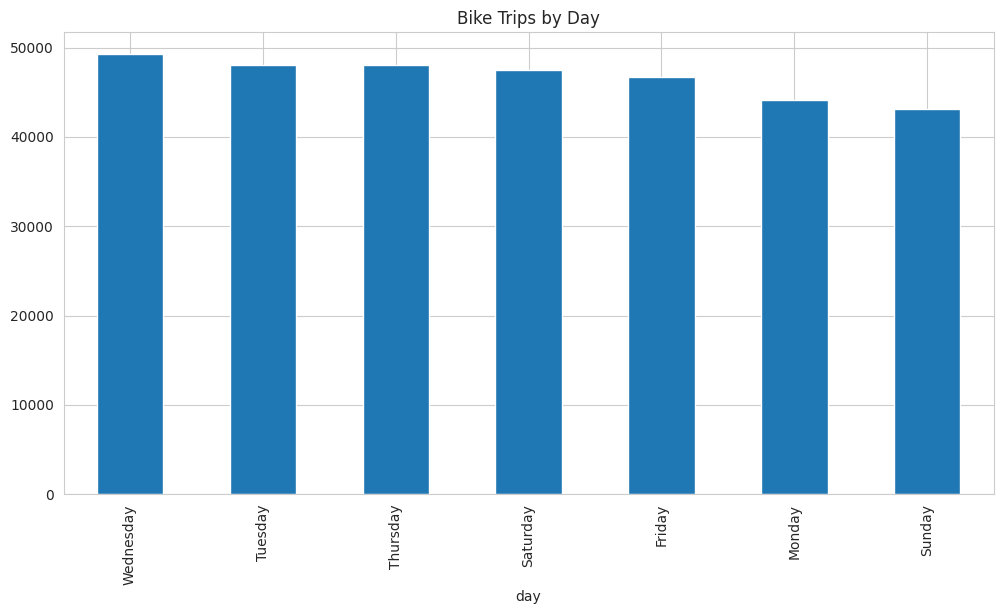

In [88]:
bike_df['day'].value_counts().plot(kind='bar')
plt.title('Bike Trips by Day')
plt.show()

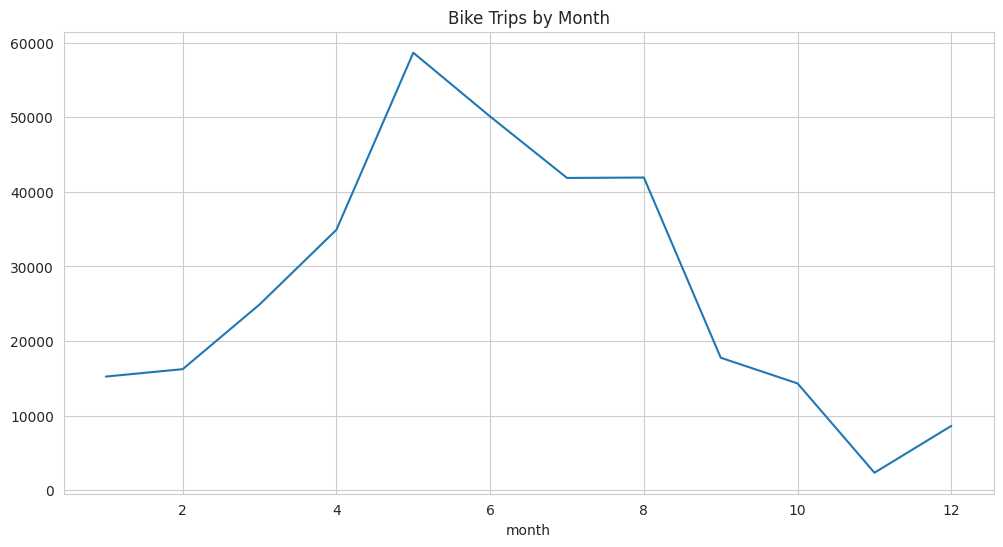

In [89]:
bike_df['month'].value_counts().sort_index().plot()
plt.title('Bike Trips by Month')
plt.show()

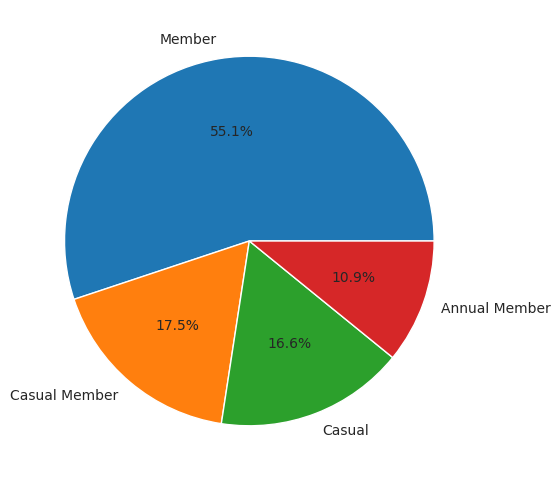

In [90]:
bike_df['user_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel('')
plt.show()

<Axes: xlabel='start_station_name'>

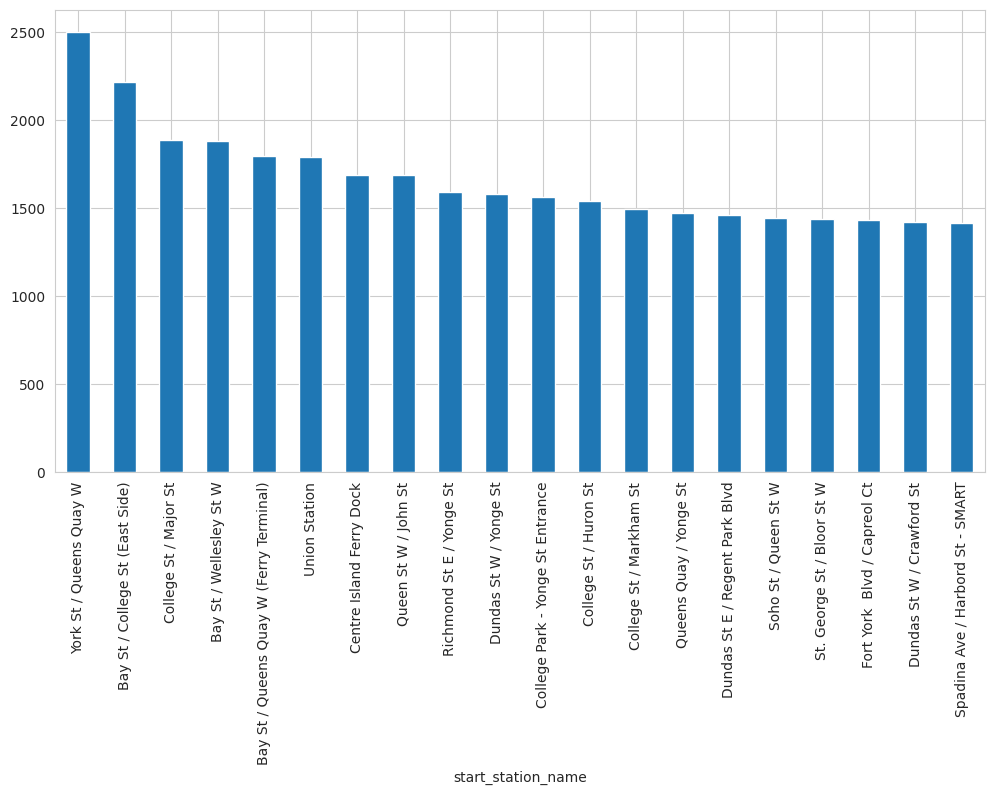

In [91]:
bike_df['start_station_name'] \
    .value_counts() \
    .head(20) \
    .plot(kind='bar')

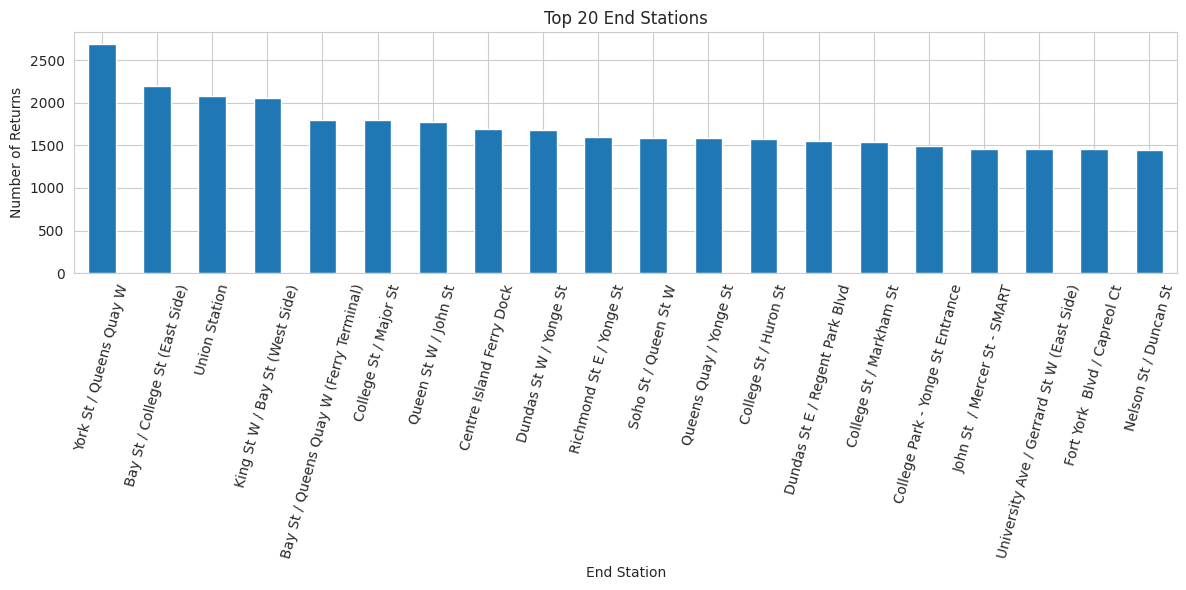

In [92]:
top_end = bike_df["end_station_name"].value_counts().head(20)

plt.figure(figsize=(12,6))
top_end.plot(kind="bar")

plt.title("Top 20 End Stations")
plt.xlabel("End Station")
plt.ylabel("Number of Returns")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()



In [93]:
climate_df = pd.read_csv(
    '/content/toronto_weather_cleaned_2021_2025.csv'
)

In [94]:
climate_df.shape
climate_df.head()
climate_df.info()
climate_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43092 entries, 0 to 43091
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   longitude          43092 non-null  float64
 1   latitude           43092 non-null  float64
 2   station_name       43092 non-null  object 
 3   date_time_lst      43092 non-null  object 
 4   year               43092 non-null  int64  
 5   month              43092 non-null  int64  
 6   day                43092 non-null  int64  
 7   time_lst           43092 non-null  object 
 8   temp_°c            43092 non-null  float64
 9   dew_point_temp_°c  43092 non-null  float64
 10  rel_hum_%          43092 non-null  float64
 11  wind_dir_10s_deg   43092 non-null  float64
 12  wind_spd_km_h      43092 non-null  float64
 13  visibility_km      43092 non-null  float64
 14  stn_press_kpa      43092 non-null  float64
 15  weather            43092 non-null  object 
dtypes: float64(9), int64(3

,longitude,latitude,year,month,day,temp_°c,dew_point_temp_°c,rel_hum_%,wind_dir_10s_deg,wind_spd_km_h,visibility_km,stn_press_kpa
count,4.309200e+04,4.309200e+04,43092.000000,43092.000000,43092.000000,43092.000000,43092.000000,43092.000000,43092.000000,43092.000000,43092.000000,43092.000000
mean,-7.963000e+01,4.368000e+01,2022.999095,6.523253,15.724079,9.922675,4.156709,69.894203,21.338717,15.991785,21.976745,99.495819
std,7.628475e-11,1.630004e-11,1.413532,3.452209,8.800971,10.639229,9.998662,17.977608,10.133036,8.908466,5.427322,0.765625
min,-7.963000e+01,4.368000e+01,2021.000000,1.000000,1.000000,-21.800000,-30.100000,15.000000,1.000000,3.000000,0.000000,95.700000
25%,-7.963000e+01,4.368000e+01,2022.000000,4.000000,8.000000,1.300000,-3.100000,58.000000,14.000000,9.000000,24.100000,99.030000
50%,-7.963000e+01,4.368000e+01,2023.000000,7.000000,16.000000,9.800000,4.000000,70.000000,24.000000,14.000000,24.100000,99.520000
75%,-7.963000e+01,4.368000e+01,2024.000000,10.000000,23.000000,19.100000,12.600000,83.000000,30.000000,21.000000,24.100000,100.010000
max,-7.963000e+01,4.368000e+01,2025.000000,12.000000,31.000000,35.800000,26.000000,100.000000,36.000000,67.000000,80.500000,102.500000


In [95]:
climate_df.isnull().sum()

,0
longitude,0
latitude,0
station_name,0
date_time_lst,0
year,0
month,0
day,0
time_lst,0
temp_°c,0
dew_point_temp_°c,0


In [96]:
climate_df.duplicated().sum()

np.int64(0)

In [97]:
climate_df['date_time_lst'] = pd.to_datetime(
    climate_df['date_time_lst']
)

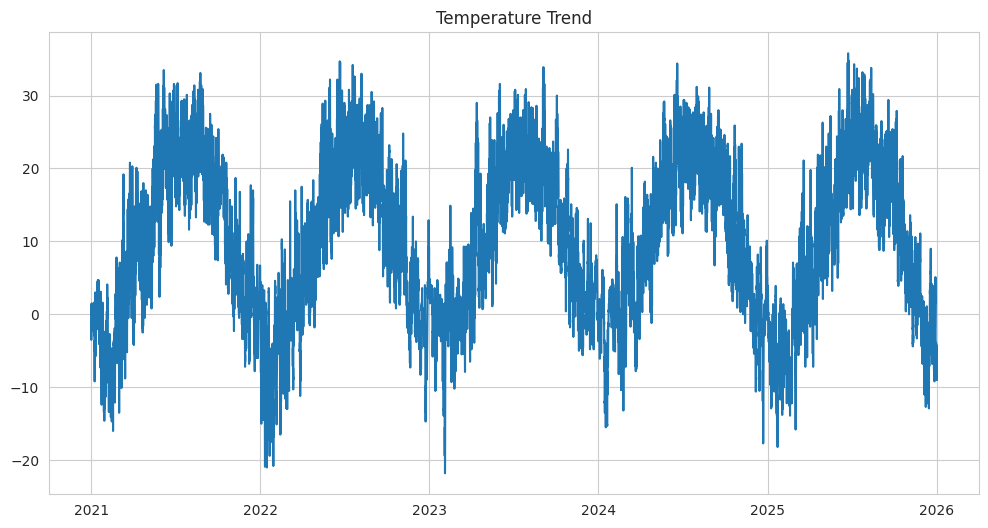

In [98]:
plt.plot(
    climate_df['date_time_lst'],
    climate_df['temp_°c']
)
plt.title('Temperature Trend')
plt.show()

<Axes: xlabel='month'>

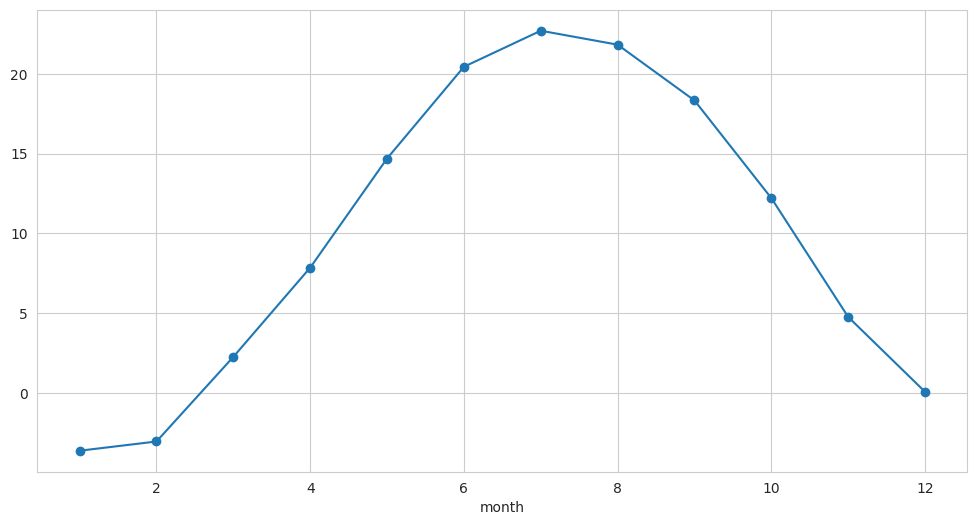

In [99]:
climate_df['month'] = climate_df[
    'date_time_lst'
].dt.month

climate_df.groupby('month')['temp_°c'] \
    .mean() \
    .plot(marker='o')

<Axes: xlabel='rel_hum_%', ylabel='Count'>

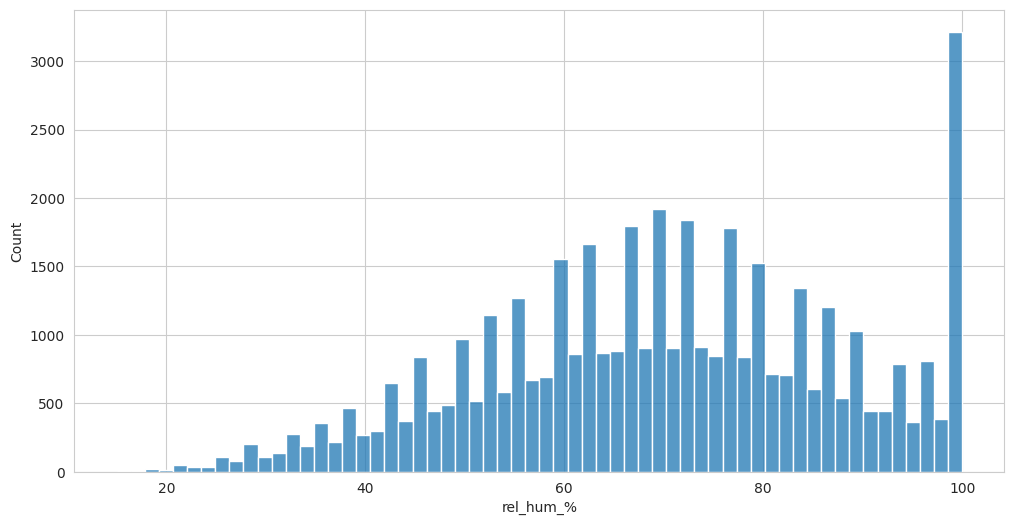

In [100]:
sns.histplot(
    climate_df['rel_hum_%']
)

<Axes: >

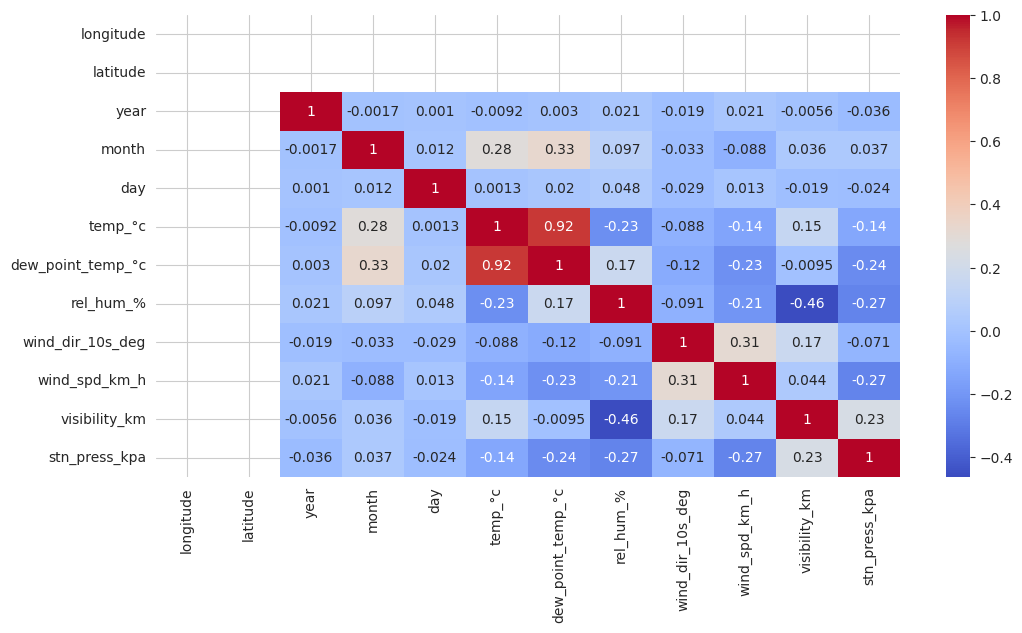

In [101]:
numeric_cols = climate_df.select_dtypes(
    include=np.number
)

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

In [102]:
events_df = pd.read_csv(
    '/content/toronto_calendar_events_2021_2025.csv'
)

In [103]:
events_df.shape
events_df.head()
events_df.info()
events_df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   event_date    77 non-null     object
 1   event_name    77 non-null     object
 2   event_type    77 non-null     object
 3   location      77 non-null     object
 4   impact_level  77 non-null     object
 5   year          77 non-null     int64 
 6   month         77 non-null     int64 
 7   day_of_week   77 non-null     object
 8   is_event      77 non-null     int64 
dtypes: int64(3), object(6)
memory usage: 5.5+ KB


,event_date,event_name,event_type,location,impact_level,year,month,day_of_week,is_event
count,77,77,77,77,77,77.000000,77.000000,77,77.0
unique,73,17,4,7,2,NaN,NaN,7,NaN
top,2023-10-20,New Year's Day,Public Holiday,Toronto,High,NaN,NaN,Monday,NaN
freq,2,5,45,45,61,NaN,NaN,26,NaN
mean,NaN,NaN,NaN,NaN,NaN,2022.792208,7.285714,NaN,1.0
std,NaN,NaN,NaN,NaN,NaN,1.331181,3.343718,NaN,0.0
min,NaN,NaN,NaN,NaN,NaN,2021.000000,1.000000,NaN,1.0
25%,NaN,NaN,NaN,NaN,NaN,2022.000000,5.000000,NaN,1.0
50%,NaN,NaN,NaN,NaN,NaN,2023.000000,8.000000,NaN,1.0
75%,NaN,NaN,NaN,NaN,NaN,2024.000000,10.000000,NaN,1.0


In [104]:
events_df.isnull().sum()

,0
event_date,0
event_name,0
event_type,0
location,0
impact_level,0
year,0
month,0
day_of_week,0
is_event,0


In [105]:
events_df.duplicated().sum()

np.int64(0)

In [106]:
events_df.drop_duplicates(inplace=True)

In [107]:
events_df['event_date'] = pd.to_datetime(
    events_df['event_date']
)

In [108]:
events_df['year'] = events_df[
    'event_date'
].dt.year

events_df['month'] = events_df[
    'event_date'
].dt.month

events_df['day_name'] = events_df[
    'event_date'
].dt.day_name()

events_df['is_event'] = 1

<Axes: xlabel='year'>

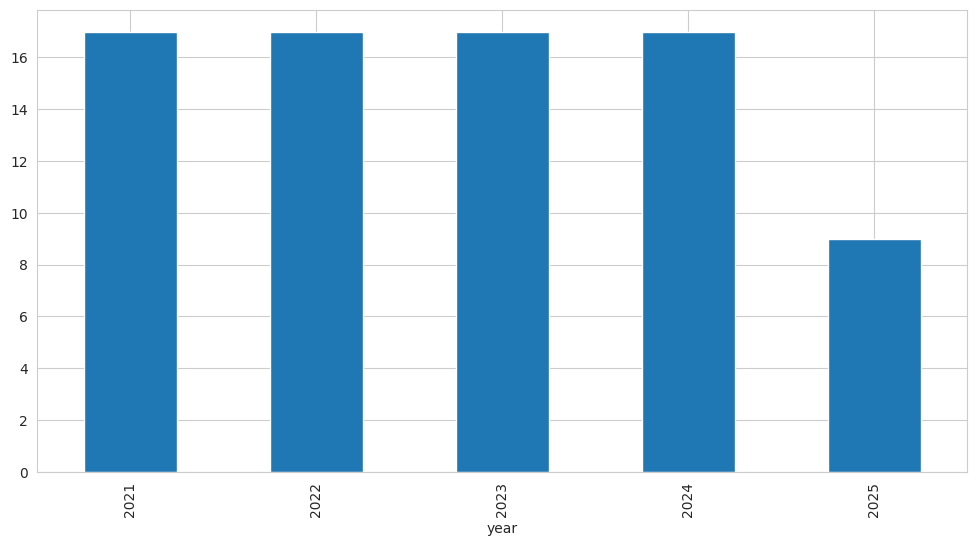

In [109]:
events_df['year'].value_counts() \
    .sort_index() \
    .plot(kind='bar')

<Axes: xlabel='event_type'>

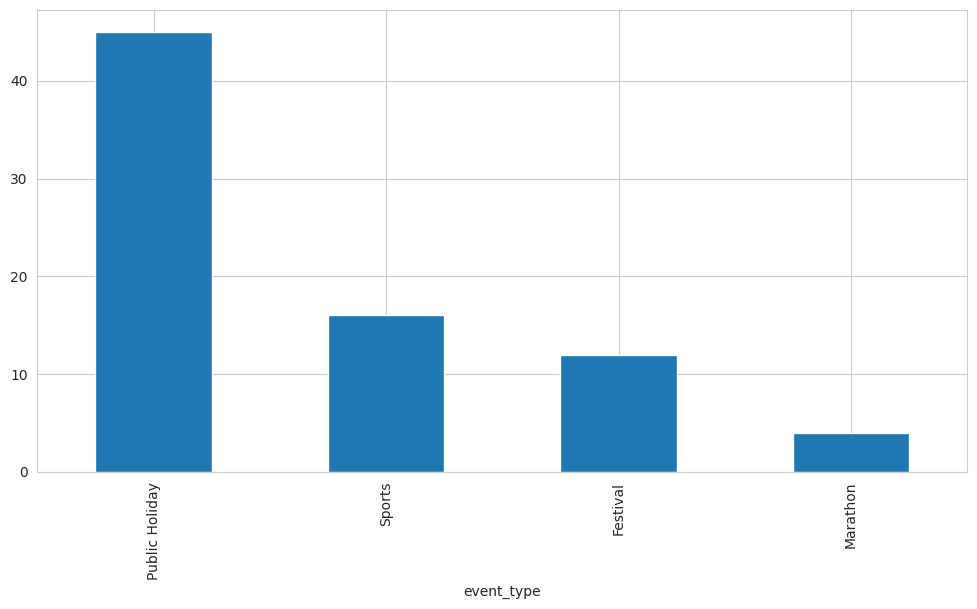

In [110]:
events_df['event_type'] \
    .value_counts() \
    .plot(kind='bar')

<Axes: ylabel='count'>

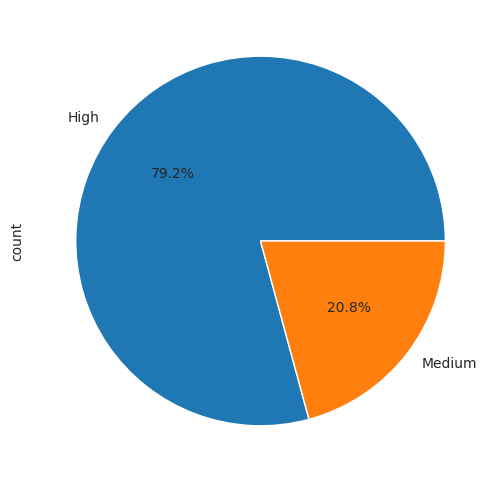

In [111]:
events_df['impact_level'] \
    .value_counts() \
    .plot(kind='pie',
          autopct='%1.1f%%')

<Axes: xlabel='month'>

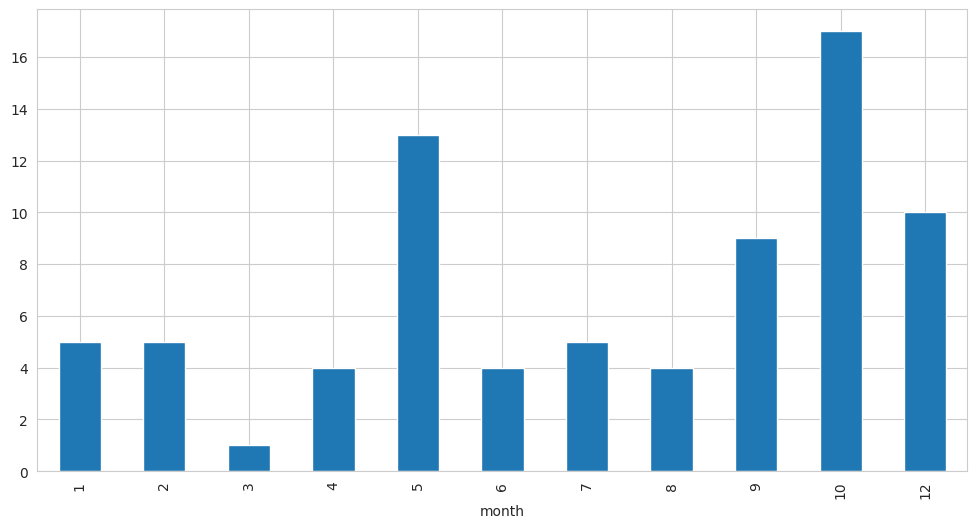

In [112]:
events_df['month'] \
    .value_counts() \
    .sort_index() \
    .plot(kind='bar')

In [113]:
bike_df.to_csv(
    'bike_cleaned.csv',
    index=False
)

climate_df.to_csv(
    'climate_cleaned.csv',
    index=False
)

events_df.to_csv(
    'events_cleaned.csv',
    index=False
)

In [114]:
import pandas as pd
import numpy as np

In [115]:
print("Bike dataset:", bike_df.shape)
print("Climate dataset:", climate_df.shape)
print("Events dataset:", events_df.shape)

Bike dataset: (326853, 15)
Climate dataset: (43092, 16)
Events dataset: (77, 10)


In [116]:
print("\nBike columns:")
print(bike_df.columns.tolist())

print("\nClimate columns:")
print(climate_df.columns.tolist())

print("\nEvent columns:")
print(events_df.columns.tolist())


Bike columns:
['trip_id', 'start_station_id', 'start_time', 'start_station_name', 'end_station_id', 'end_time', 'end_station_name', 'bike_id', 'user_type', 'hour', 'day', 'month', 'trip_duration', 'year', 'weekend']

Climate columns:
['longitude', 'latitude', 'station_name', 'date_time_lst', 'year', 'month', 'day', 'time_lst', 'temp_°c', 'dew_point_temp_°c', 'rel_hum_%', 'wind_dir_10s_deg', 'wind_spd_km_h', 'visibility_km', 'stn_press_kpa', 'weather']

Event columns:
['event_date', 'event_name', 'event_type', 'location', 'impact_level', 'year', 'month', 'day_of_week', 'is_event', 'day_name']


In [117]:
bike_df["start_time"] = pd.to_datetime(
    bike_df["start_time"],
    errors="coerce"
)

bike_df["end_time"] = pd.to_datetime(
    bike_df["end_time"],
    errors="coerce"
)

climate_df["date_time_lst"] = pd.to_datetime(
    climate_df["date_time_lst"],
    errors="coerce"
)

events_df["event_date"] = pd.to_datetime(
    events_df["event_date"],
    errors="coerce"
)

In [118]:
bike_df = bike_df.dropna(subset=["start_time"])
climate_df = climate_df.dropna(subset=["date_time_lst"])
events_df = events_df.dropna(subset=["event_date"])

In [119]:
bike_df["start_hour"] = bike_df["start_time"].dt.floor("h")

In [120]:
hourly_demand = (
    bike_df.groupby("start_hour")
    .size()
    .reset_index(name="trip_count")
    .rename(columns={"start_hour": "datetime"})
)

In [121]:
print("Hourly bike-demand shape:", hourly_demand.shape)
display(hourly_demand.head())

Hourly bike-demand shape: (18616, 2)


,datetime,trip_count
0,2022-01-01 00:00:00,1
1,2022-01-01 01:00:00,2
2,2022-01-01 02:00:00,4
3,2022-01-01 03:00:00,1
4,2022-01-01 07:00:00,1


In [122]:
complete_hours = pd.date_range(
    start=hourly_demand["datetime"].min(),
    end=hourly_demand["datetime"].max(),
    freq="h"
)

hourly_demand = (
    hourly_demand.set_index("datetime")
    .reindex(complete_hours, fill_value=0)
    .rename_axis("datetime")
    .reset_index()
)

In [123]:
print("Complete hourly-demand shape:", hourly_demand.shape)

Complete hourly-demand shape: (35064, 2)


In [124]:
climate_df["datetime"] = (
    climate_df["date_time_lst"]
    .dt.floor("h")
)

In [125]:
weather_columns = [
    "datetime",
    "temp_°c",
    "dew_point_temp_°c",
    "rel_hum_%",
    "wind_dir_10s_deg",
    "wind_spd_km_h",
    "visibility_km",
    "stn_press_kpa"
]

weather_columns = [
    column for column in weather_columns
    if column in climate_df.columns
]

weather_hourly = climate_df[weather_columns].copy()

In [126]:
weather_hourly = (
    weather_hourly.groupby("datetime", as_index=False)
    .mean(numeric_only=True)
)

In [127]:
print("Hourly weather shape:", weather_hourly.shape)
display(weather_hourly.head())

Hourly weather shape: (43092, 8)


,datetime,temp_°c,dew_point_temp_°c,rel_hum_%,wind_dir_10s_deg,wind_spd_km_h,visibility_km,stn_press_kpa
0,2021-01-01 00:00:00,-2.4,-6.4,74.0,27.0,3.0,24.1,100.93
1,2021-01-01 01:00:00,-1.9,-6.2,72.0,15.0,3.0,24.1,100.93
2,2021-01-01 02:00:00,-2.3,-6.2,75.0,18.0,5.0,24.1,100.95
3,2021-01-01 03:00:00,-3.5,-6.1,82.0,26.0,4.0,24.1,101.03
4,2021-01-01 04:00:00,-3.2,-5.7,83.0,26.0,5.0,24.1,101.02


In [128]:
bike_weather_df = pd.merge(
    hourly_demand,
    weather_hourly,
    on="datetime",
    how="left",
    validate="one_to_one"
)

In [129]:
print("Bike + weather shape:", bike_weather_df.shape)

print("\nMissing values after weather merge:")
print(bike_weather_df.isnull().sum())

Bike + weather shape: (35064, 9)

Missing values after weather merge:
datetime               0
trip_count             0
temp_°c              590
dew_point_temp_°c    590
rel_hum_%            590
wind_dir_10s_deg     590
wind_spd_km_h        590
visibility_km        590
stn_press_kpa        590
dtype: int64


In [130]:
weather_numeric_columns = [
    column for column in weather_hourly.columns
    if column != "datetime"
]

bike_weather_df = bike_weather_df.sort_values("datetime")

bike_weather_df[weather_numeric_columns] = (
    bike_weather_df[weather_numeric_columns]
    .interpolate(method="linear", limit_direction="both")
)

In [131]:
print(bike_weather_df.isnull().sum())

datetime             0
trip_count           0
temp_°c              0
dew_point_temp_°c    0
rel_hum_%            0
wind_dir_10s_deg     0
wind_spd_km_h        0
visibility_km        0
stn_press_kpa        0
dtype: int64


In [132]:
text_columns = [
    "event_name",
    "event_type",
    "location",
    "impact_level",
    "expected_impact"
]

for column in text_columns:
    if column in events_df.columns:
        events_df[column] = (
            events_df[column]
            .astype("string")
            .str.strip()
        )

In [133]:
events_df["date"] = events_df["event_date"].dt.normalize()

In [134]:
if "impact_level" not in events_df.columns:
    if "expected_impact" in events_df.columns:
        events_df = events_df.rename(
            columns={"expected_impact": "impact_level"}
        )
    else:
        events_df["impact_level"] = "Unknown"

In [135]:
events_df = events_df.drop_duplicates(
    subset=[
        "date",
        "event_name",
        "event_type",
        "location"
    ]
)

In [136]:
impact_mapping = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

events_df["event_impact_score"] = (
    events_df["impact_level"]
    .map(impact_mapping)
    .fillna(0)
    .astype(int)
)

In [137]:
daily_events = (
    events_df.groupby("date", as_index=False)
    .agg(
        event_count=("event_name", "count"),
        event_names=(
            "event_name",
            lambda values: " | ".join(
                sorted(set(values.dropna().astype(str)))
            )
        ),
        event_types=(
            "event_type",
            lambda values: " | ".join(
                sorted(set(values.dropna().astype(str)))
            )
        ),
        event_locations=(
            "location",
            lambda values: " | ".join(
                sorted(set(values.dropna().astype(str)))
            )
        ),
        maximum_event_impact=("event_impact_score", "max")
    )
)

In [138]:
daily_events["is_event"] = 1

In [139]:
print("Daily event dataset shape:", daily_events.shape)
display(daily_events.head())

Daily event dataset shape: (73, 7)


,date,event_count,event_names,event_types,event_locations,maximum_event_impact,is_event
0,2021-01-01,1,New Year's Day,Public Holiday,Toronto,3,1
1,2021-02-15,1,Family Day,Public Holiday,Toronto,3,1
2,2021-04-02,1,Good Friday,Public Holiday,Toronto,3,1
3,2021-05-01,1,Blue Jays Season Start,Sports,Rogers Centre,2,1
4,2021-05-15,1,Toronto FC Season,Sports,BMO Field,2,1


In [140]:
bike_weather_df["date"] = (
    bike_weather_df["datetime"]
    .dt.normalize()
)

In [141]:
final_df = pd.merge(
    bike_weather_df,
    daily_events,
    on="date",
    how="left",
    validate="many_to_one"
)

In [142]:
final_df["is_event"] = (
    final_df["is_event"]
    .fillna(0)
    .astype(int)
)

final_df["event_count"] = (
    final_df["event_count"]
    .fillna(0)
    .astype(int)
)

final_df["maximum_event_impact"] = (
    final_df["maximum_event_impact"]
    .fillna(0)
    .astype(int)
)

In [143]:
for column in [
    "event_names",
    "event_types",
    "event_locations"
]:
    final_df[column] = final_df[column].fillna("No Event")

In [144]:
final_df["year"] = final_df["datetime"].dt.year
final_df["month"] = final_df["datetime"].dt.month
final_df["day"] = final_df["datetime"].dt.day
final_df["hour"] = final_df["datetime"].dt.hour
final_df["day_of_week"] = final_df["datetime"].dt.dayofweek
final_df["day_name"] = final_df["datetime"].dt.day_name()

final_df["is_weekend"] = (
    final_df["day_of_week"] >= 5
).astype(int)

final_df["is_rush_hour"] = (
    final_df["hour"]
    .isin([7, 8, 9, 16, 17, 18])
    .astype(int)
)

In [145]:
def assign_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    return "Fall"


final_df["season"] = (
    final_df["month"]
    .apply(assign_season)
)

In [146]:
print("Final merged shape:", final_df.shape)

print("\nDate range:")
print(final_df["datetime"].min())
print(final_df["datetime"].max())

print("\nMissing values:")
print(final_df.isnull().sum())

print("\nDuplicate hourly timestamps:")
print(final_df["datetime"].duplicated().sum())

display(final_df.head())

Final merged shape: (35064, 25)

Date range:
2022-01-01 00:00:00
2025-12-31 23:00:00

Missing values:
datetime                0
trip_count              0
temp_°c                 0
dew_point_temp_°c       0
rel_hum_%               0
wind_dir_10s_deg        0
wind_spd_km_h           0
visibility_km           0
stn_press_kpa           0
date                    0
event_count             0
event_names             0
event_types             0
event_locations         0
maximum_event_impact    0
is_event                0
year                    0
month                   0
day                     0
hour                    0
day_of_week             0
day_name                0
is_weekend              0
is_rush_hour            0
season                  0
dtype: int64

Duplicate hourly timestamps:
0


,datetime,trip_count,temp_°c,dew_point_temp_°c,rel_hum_%,wind_dir_10s_deg,wind_spd_km_h,visibility_km,stn_press_kpa,date,...,is_event,year,month,day,hour,day_of_week,day_name,is_weekend,is_rush_hour,season
0,2022-01-01 00:00:00,1,3.9,3.9,100.0,5.0,4.0,4.8,98.66,2022-01-01,...,1,2022,1,1,0,5,Saturday,1,0,Winter
1,2022-01-01 01:00:00,2,4.2,4.2,100.0,4.0,11.0,4.8,98.57,2022-01-01,...,1,2022,1,1,1,5,Saturday,1,0,Winter
2,2022-01-01 02:00:00,4,4.2,4.2,100.0,6.0,10.0,4.8,98.47,2022-01-01,...,1,2022,1,1,2,5,Saturday,1,0,Winter
3,2022-01-01 03:00:00,1,4.1,4.1,100.0,1.0,10.0,4.8,98.50,2022-01-01,...,1,2022,1,1,3,5,Saturday,1,0,Winter
4,2022-01-01 04:00:00,0,4.5,4.5,100.0,10.0,12.0,4.8,98.45,2022-01-01,...,1,2022,1,1,4,5,Saturday,1,0,Winter


In [147]:
print(final_df["is_event"].value_counts())

print(
    final_df["is_event"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

is_event
0    33696
1     1368
Name: count, dtype: int64
is_event
0    96.1
1     3.9
Name: proportion, dtype: float64


In [148]:
event_demand_summary = (
    final_df.groupby("is_event")["trip_count"]
    .agg(["count", "mean", "median", "std", "max"])
)

event_demand_summary.index = [
    "Non-Event Hours",
    "Event-Day Hours"
]

display(event_demand_summary)

,count,mean,median,std,max
Non-Event Hours,33696,9.365622,1.0,16.935060,189
Event-Day Hours,1368,8.237573,0.0,17.141943,127


In [149]:
normal_demand = final_df.loc[
    final_df["is_event"] == 0,
    "trip_count"
].mean()

event_demand = final_df.loc[
    final_df["is_event"] == 1,
    "trip_count"
].mean()

event_effect_percentage = (
    (event_demand - normal_demand)
    / normal_demand
) * 100

print(
    f"Average hourly demand on non-event days: "
    f"{normal_demand:.2f}"
)

print(
    f"Average hourly demand on event days: "
    f"{event_demand:.2f}"
)

print(
    f"Estimated event-day demand change: "
    f"{event_effect_percentage:.2f}%"
)

Average hourly demand on non-event days: 9.37
Average hourly demand on event days: 8.24
Estimated event-day demand change: -12.04%


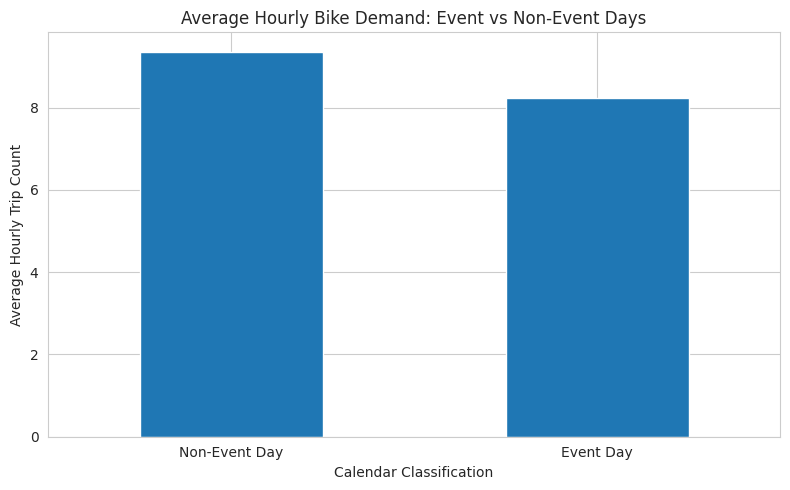

In [150]:
import matplotlib.pyplot as plt

event_plot = (
    final_df.groupby("is_event")["trip_count"]
    .mean()
)

event_plot.index = [
    "Non-Event Day",
    "Event Day"
]

event_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Hourly Bike Demand: Event vs Non-Event Days")
plt.xlabel("Calendar Classification")
plt.ylabel("Average Hourly Trip Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [151]:
from google.colab import files

download_name = "bike_weather_events_merged_2021_2025.csv"

final_df.to_csv(
    download_name,
    index=False
)

files.download(download_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [152]:
import pandas as pd
import numpy as np


file_path = "/content/hourly_bikeshare_2021_2025.csv"

df = pd.read_csv(file_path)

print("Original shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst five rows:")
print(df.head())



df["hour_timestamp"] = pd.to_datetime(
    df["hour_timestamp"],
    errors="coerce"
)

df["trip_count"] = pd.to_numeric(
    df["trip_count"],
    errors="coerce"
)


df = df.dropna(
    subset=["hour_timestamp", "trip_count"]
).copy()

df = df.sort_values(
    "hour_timestamp"
).reset_index(drop=True)

print("\nDate range:")
print(df["hour_timestamp"].min())
print(df["hour_timestamp"].max())



expected_hours = pd.date_range(
    start=df["hour_timestamp"].min(),
    end=df["hour_timestamp"].max(),
    freq="h"
)

missing_hours = expected_hours.difference(
    df["hour_timestamp"]
)

print("\nNumber of missing hourly timestamps:")
print(len(missing_hours))


df["year"] = df["hour_timestamp"].dt.year
df["month"] = df["hour_timestamp"].dt.month
df["day"] = df["hour_timestamp"].dt.day
df["hour"] = df["hour_timestamp"].dt.hour

df["day_of_week_number"] = (
    df["hour_timestamp"].dt.dayofweek
)

df["day_of_week"] = (
    df["hour_timestamp"].dt.day_name()
)

df["is_weekend"] = (
    df["day_of_week_number"]
    .isin([5, 6])
    .astype(int)
)


df["lag_1"] = df["trip_count"].shift(1)

df["lag_2"] = df["trip_count"].shift(2)

df["lag_3"] = df["trip_count"].shift(3)

df["lag_24"] = df["trip_count"].shift(24)

df["lag_48"] = df["trip_count"].shift(48)

df["lag_168"] = df["trip_count"].shift(168)


df["rolling_mean_3"] = (
    df["trip_count"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

df["rolling_mean_6"] = (
    df["trip_count"]
    .shift(1)
    .rolling(window=6)
    .mean()
)

df["rolling_mean_24"] = (
    df["trip_count"]
    .shift(1)
    .rolling(window=24)
    .mean()
)

df["rolling_mean_168"] = (
    df["trip_count"]
    .shift(1)
    .rolling(window=168)
    .mean()
)

df["rolling_std_24"] = (
    df["trip_count"]
    .shift(1)
    .rolling(window=24)
    .std()
)



df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

df["weekday_sin"] = np.sin(
    2 * np.pi * df["day_of_week_number"] / 7
)

df["weekday_cos"] = np.cos(
    2 * np.pi * df["day_of_week_number"] / 7
)

df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)


required_features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_24",
    "rolling_mean_168",
    "rolling_std_24"
]

model_data = df.dropna(
    subset=required_features
).copy()


print("\nOriginal hourly rows:", len(df))
print("Model-ready rows:", len(model_data))

print("\nModel-ready columns:")
print(model_data.columns.tolist())

print("\nFirst five model-ready rows:")
print(model_data.head())

print("\nMissing values:")
print(model_data.isnull().sum())


output_path = (
    "/content/hourly_bikeshare_model_ready_2021_2025.csv"
)

model_data.to_csv(
    output_path,
    index=False
)

print("\nFile saved successfully:")
print(output_path)

Original shape: (43824, 9)

Columns:
['hour_timestamp', 'trip_count', 'year', 'month', 'day', 'hour', 'day_of_week', 'day_of_week_number', 'is_weekend']

First five rows:
        hour_timestamp  trip_count  year  month  day  hour day_of_week  \
0  2021-01-01 00:00:00        79.0  2021      1    1     0      Friday   
1  2021-01-01 01:00:00        56.0  2021      1    1     1      Friday   
2  2021-01-01 02:00:00        28.0  2021      1    1     2      Friday   
3  2021-01-01 03:00:00        14.0  2021      1    1     3      Friday   
4  2021-01-01 04:00:00        18.0  2021      1    1     4      Friday   

   day_of_week_number  is_weekend  
0                   4           0  
1                   4           0  
2                   4           0  
3                   4           0  
4                   4           0  

Date range:
2021-01-01 00:00:00
2025-12-31 23:00:00

Number of missing hourly timestamps:
720

Original hourly rows: 43104
Model-ready rows: 42936

Model-ready columns

In [153]:


bike = pd.read_csv(
    "/content/hourly_bikeshare_model_ready_2021_2025.csv",
    parse_dates=["hour_timestamp"]
)

print(bike.shape)
print(bike.columns.tolist())
print(bike.head())

(42936, 26)
['hour_timestamp', 'trip_count', 'year', 'month', 'day', 'hour', 'day_of_week', 'day_of_week_number', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_24', 'rolling_mean_168', 'rolling_std_24', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos']
       hour_timestamp  trip_count  year  month  day  hour day_of_week  \
0 2021-01-08 00:00:00        27.0  2021      1    8     0      Friday   
1 2021-01-08 01:00:00        15.0  2021      1    8     1      Friday   
2 2021-01-08 02:00:00         8.0  2021      1    8     2      Friday   
3 2021-01-08 03:00:00         6.0  2021      1    8     3      Friday   
4 2021-01-08 04:00:00         9.0  2021      1    8     4      Friday   

   day_of_week_number  is_weekend  lag_1  ...  rolling_mean_6  \
0                   4           0   55.0  ...      149.833333   
1                   4           0   27.0  ...      107.333333   
2      

Experiment 1

In [154]:
train = model_data[model_data["year"] < 2025]
test = model_data[model_data["year"] == 2025]

print("Training rows:", len(train))
print("Testing rows:", len(test))

Training rows: 34176
Testing rows: 8760


In [155]:
features = [
    "hour",
    "month",
    "day_of_week_number",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_24",
    "rolling_mean_168",
    "rolling_std_24",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos"
]

X_train = train[features]
y_train = train["trip_count"]

X_test = test[features]
y_test = test["trip_count"]

In [156]:
historical_average = (
    train.groupby(
        ["month", "hour", "day_of_week_number"]
    )["trip_count"]
    .mean()
    .reset_index()
)

historical_average.columns = [
    "month",
    "hour",
    "day_of_week_number",
    "prediction"
]

test_hist = test.merge(
    historical_average,
    on=["month", "hour", "day_of_week_number"],
    how="left"
)

hist_predictions = test_hist["prediction"]

In [157]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_predictions = lr.predict(X_test)

In [158]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

In [159]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb = HistGradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

gb_predictions = gb.predict(X_test)

In [160]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

def evaluate(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    print(f"\n{name}")
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R²  :", round(r2, 3))

evaluate("Historical Average", y_test, hist_predictions)
evaluate("Linear Regression", y_test, lr_predictions)
evaluate("Random Forest", y_test, rf_predictions)
evaluate("Gradient Boosting", y_test, gb_predictions)


Historical Average
MAE : 345.25
RMSE: 540.2
R²  : 0.671

Linear Regression
MAE : 148.09
RMSE: 252.66
R²  : 0.928

Random Forest
MAE : 103.06
RMSE: 204.28
R²  : 0.953

Gradient Boosting
MAE : 92.69
RMSE: 171.31
R²  : 0.967


In [161]:
climate = pd.read_csv("/content/toronto_weather_cleaned_2021_2025.csv")
events = pd.read_csv("/content/toronto_calendar_events_2021_2025.csv")

print("Climate columns:")
print(climate.columns.tolist())

print("\nEvent columns:")
print(events.columns.tolist())

Climate columns:
['longitude', 'latitude', 'station_name', 'date_time_lst', 'year', 'month', 'day', 'time_lst', 'temp_°c', 'dew_point_temp_°c', 'rel_hum_%', 'wind_dir_10s_deg', 'wind_spd_km_h', 'visibility_km', 'stn_press_kpa', 'weather']

Event columns:
['event_date', 'event_name', 'event_type', 'location', 'impact_level', 'year', 'month', 'day_of_week', 'is_event']


In [162]:
import pandas as pd
import numpy as np

bike_path = "/content/hourly_bikeshare_model_ready_2021_2025.csv"
climate_path = "/content/toronto_weather_cleaned_2021_2025.csv"
event_path = "/content/toronto_calendar_events_2021_2025.csv"

bike = pd.read_csv(bike_path, low_memory=False)
climate = pd.read_csv(climate_path, low_memory=False)
events = pd.read_csv(event_path, low_memory=False)

print("Bike shape:", bike.shape)
print("Climate shape:", climate.shape)
print("Event shape:", events.shape)

Bike shape: (42936, 26)
Climate shape: (43092, 16)
Event shape: (77, 9)


In [163]:
bike["hour_timestamp"] = pd.to_datetime(
    bike["hour_timestamp"],
    errors="coerce"
).dt.floor("h")

bike = bike.dropna(
    subset=["hour_timestamp", "trip_count"]
).copy()

bike = bike.sort_values(
    "hour_timestamp"
).reset_index(drop=True)

print(
    "Bike date range:",
    bike["hour_timestamp"].min(),
    "to",
    bike["hour_timestamp"].max()
)

Bike date range: 2021-01-08 00:00:00 to 2025-12-31 23:00:00


In [164]:
climate["hour_timestamp"] = pd.to_datetime(
    climate["date_time_lst"],
    errors="coerce"
).dt.floor("h")

climate = climate.rename(
    columns={
        "temp_°c": "temperature_c",
        "dew_point_temp_°c": "dew_point_c",
        "rel_hum_%": "relative_humidity",
        "wind_dir_10s_deg": "wind_direction",
        "wind_spd_km_h": "wind_speed_kmh",
        "visibility_km": "visibility_km",
        "stn_press_kpa": "station_pressure_kpa"
    }
)

weather_features = [
    "temperature_c",
    "dew_point_c",
    "relative_humidity",
    "wind_direction",
    "wind_speed_kmh",
    "visibility_km",
    "station_pressure_kpa"
]

for column in weather_features:
    climate[column] = pd.to_numeric(
        climate[column],
        errors="coerce"
    )

climate_hourly = (
    climate[
        ["hour_timestamp"] + weather_features
    ]
    .dropna(subset=["hour_timestamp"])
    .groupby(
        "hour_timestamp",
        as_index=False
    )
    .mean(numeric_only=True)
)

print("Climate hourly shape:", climate_hourly.shape)

print(
    "Climate date range:",
    climate_hourly["hour_timestamp"].min(),
    "to",
    climate_hourly["hour_timestamp"].max()
)

print("\nClimate missing values:")
print(climate_hourly.isnull().sum())

Climate hourly shape: (43092, 8)
Climate date range: 2021-01-01 00:00:00 to 2025-12-31 23:00:00

Climate missing values:
hour_timestamp          0
temperature_c           0
dew_point_c             0
relative_humidity       0
wind_direction          0
wind_speed_kmh          0
visibility_km           0
station_pressure_kpa    0
dtype: int64


In [165]:
events["event_date"] = pd.to_datetime(
    events["event_date"],
    errors="coerce"
).dt.normalize()

events = events.dropna(
    subset=["event_date"]
).copy()

events["is_event"] = pd.to_numeric(
    events["is_event"],
    errors="coerce"
).fillna(1).astype(int)

In [166]:
impact_mapping = {
    "low": 1,
    "medium": 2,
    "moderate": 2,
    "high": 3,
    "major": 3
}

events["event_impact"] = (
    events["impact_level"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(impact_mapping)
    .fillna(1)
    .astype(int)
)

In [167]:
events_daily = (
    events.groupby(
        "event_date",
        as_index=False
    )
    .agg(
        event_count=("event_name", "count"),
        is_event=("is_event", "max"),
        maximum_event_impact=("event_impact", "max")
    )
)

print("Event-day shape:", events_daily.shape)

print(
    "Event date range:",
    events_daily["event_date"].min(),
    "to",
    events_daily["event_date"].max()
)

print(events_daily.head())

Event-day shape: (73, 4)
Event date range: 2021-01-01 00:00:00 to 2025-12-26 00:00:00
  event_date  event_count  is_event  maximum_event_impact
0 2021-01-01            1         1                     3
1 2021-02-15            1         1                     3
2 2021-04-02            1         1                     3
3 2021-05-01            1         1                     2
4 2021-05-15            1         1                     2


In [168]:
combined = bike.merge(
    climate_hourly,
    on="hour_timestamp",
    how="left"
)

print("Shape after climate merge:", combined.shape)

print("\nWeather missing values after merge:")
print(combined[weather_features].isnull().sum())

Shape after climate merge: (42936, 33)

Weather missing values after merge:
temperature_c           718
dew_point_c             718
relative_humidity       718
wind_direction          718
wind_speed_kmh          718
visibility_km           718
station_pressure_kpa    718
dtype: int64


In [169]:
combined = combined.sort_values(
    "hour_timestamp"
).reset_index(drop=True)

combined[weather_features] = (
    combined[weather_features]
    .interpolate(
        method="linear",
        limit_direction="both"
    )
)

print("\nWeather missing values after interpolation:")
print(
    combined[weather_features]
    .isnull()
    .sum()
)


Weather missing values after interpolation:
temperature_c           0
dew_point_c             0
relative_humidity       0
wind_direction          0
wind_speed_kmh          0
visibility_km           0
station_pressure_kpa    0
dtype: int64


In [170]:
print("Combined columns:")
print(combined.columns.tolist())

print("\nEvents daily columns:")
print(events_daily.columns.tolist())

Combined columns:
['hour_timestamp', 'trip_count', 'year', 'month', 'day', 'hour', 'day_of_week', 'day_of_week_number', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_24', 'rolling_mean_168', 'rolling_std_24', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'temperature_c', 'dew_point_c', 'relative_humidity', 'wind_direction', 'wind_speed_kmh', 'visibility_km', 'station_pressure_kpa']

Events daily columns:
['event_date', 'event_count', 'is_event', 'maximum_event_impact']


In [171]:

combined = combined.drop(
    columns=[
        "event_count_x",
        "event_count_y",
        "is_event_x",
        "is_event_y",
        "maximum_event_impact_x",
        "maximum_event_impact_y"
    ],
    errors="ignore"
)

if "event_date" not in combined.columns:
    combined["event_date"] = (
        combined["hour_timestamp"]
        .dt.normalize()
    )

combined = combined.merge(
    events_daily[
        [
            "event_date",
            "event_count",
            "is_event",
            "maximum_event_impact"
        ]
    ],
    on="event_date",
    how="left"
)

for column in [
    "event_count",
    "is_event",
    "maximum_event_impact"
]:
    combined[column] = (
        combined[column]
        .fillna(0)
        .astype(int)
    )

combined = combined.drop(
    columns=["event_date"],
    errors="ignore"
)

print("Final event columns:")
print(
    combined[
        [
            "event_count",
            "is_event",
            "maximum_event_impact"
        ]
    ].head()
)

print("\nMissing event values:")
print(
    combined[
        [
            "event_count",
            "is_event",
            "maximum_event_impact"
        ]
    ].isnull().sum()
)

print("\nFinal combined shape:")
print(combined.shape)

Final event columns:
   event_count  is_event  maximum_event_impact
0            0         0                     0
1            0         0                     0
2            0         0                     0
3            0         0                     0
4            0         0                     0

Missing event values:
event_count             0
is_event                0
maximum_event_impact    0
dtype: int64

Final combined shape:
(42936, 36)


In [172]:
print("Total event hours:")
print(combined["is_event"].sum())

print("\nRows with events:")
print(
    combined.loc[
        combined["is_event"] == 1,
        [
            "hour_timestamp",
            "trip_count",
            "event_count",
            "maximum_event_impact"
        ]
    ].head(20)
)

print("\nUnique event days represented:")
print(
    combined.loc[
        combined["is_event"] == 1,
        "hour_timestamp"
    ].dt.date.nunique()
)

Total event hours:
1728

Rows with events:
         hour_timestamp  trip_count  event_count  maximum_event_impact
912 2021-02-15 00:00:00         9.0            1                     3
913 2021-02-15 01:00:00         7.0            1                     3
914 2021-02-15 02:00:00         3.0            1                     3
915 2021-02-15 03:00:00         8.0            1                     3
916 2021-02-15 04:00:00         2.0            1                     3
917 2021-02-15 05:00:00         6.0            1                     3
918 2021-02-15 06:00:00        15.0            1                     3
919 2021-02-15 07:00:00        26.0            1                     3
920 2021-02-15 08:00:00        48.0            1                     3
921 2021-02-15 09:00:00        59.0            1                     3
922 2021-02-15 10:00:00        83.0            1                     3
923 2021-02-15 11:00:00        74.0            1                     3
924 2021-02-15 12:00:00        95.

In [173]:
combined.to_csv(
    "/content/bike_climate_events_model_ready_2021_2025.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


EXPERIMENT 2

In [174]:

import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


file_path = "/content/bike_climate_events_model_ready_2021_2025.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["hour_timestamp"],
    low_memory=False
)

print("Dataset shape:", df.shape)
print("Date range:")
print(df["hour_timestamp"].min(), "to", df["hour_timestamp"].max())


bike_features = [
    "hour",
    "month",
    "day_of_week_number",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_24",
    "rolling_mean_168",
    "rolling_std_24",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos"
]

climate_features = [
    "temperature_c",
    "dew_point_c",
    "relative_humidity",
    "wind_direction",
    "wind_speed_kmh",
    "visibility_km",
    "station_pressure_kpa"
]

features = bike_features + climate_features


target = "trip_count"

missing_features = [
    column for column in features
    if column not in df.columns
]

if missing_features:
    raise ValueError(
        f"Missing columns: {missing_features}"
    )


for column in features + [target]:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

df = df.dropna(
    subset=features + [target]
).copy()

df = df.sort_values(
    "hour_timestamp"
).reset_index(drop=True)



train = df[
    df["hour_timestamp"] < "2025-01-01"
].copy()

test = df[
    df["hour_timestamp"] >= "2025-01-01"
].copy()

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("\nTraining rows:", len(train))
print("Testing rows:", len(test))

print("\nTraining period:")
print(
    train["hour_timestamp"].min(),
    "to",
    train["hour_timestamp"].max()
)

print("\nTesting period:")
print(
    test["hour_timestamp"].min(),
    "to",
    test["hour_timestamp"].max()
)


def evaluate_model(
    model_name,
    actual,
    predicted
):
    predicted = np.clip(
        predicted,
        0,
        None
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        "Experiment": "Bike Share + Climate",
        "Model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 3)
    }


results = []


historical_average = (
    train.groupby(
        [
            "month",
            "hour",
            "day_of_week_number"
        ]
    )[target]
    .mean()
    .reset_index(
        name="historical_prediction"
    )
)

test_historical = test.merge(
    historical_average,
    on=[
        "month",
        "hour",
        "day_of_week_number"
    ],
    how="left"
)

historical_predictions = (
    test_historical["historical_prediction"]
    .fillna(y_train.mean())
    .values
)

results.append(
    evaluate_model(
        "Historical Average",
        y_test,
        historical_predictions
    )
)


linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)


random_forest_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_predictions = (
    random_forest_model.predict(X_test)
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        random_forest_predictions
    )
)


gradient_boosting_model = (
    HistGradientBoostingRegressor(
        learning_rate=0.08,
        max_iter=250,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=0.1,
        random_state=42
    )
)

gradient_boosting_model.fit(
    X_train,
    y_train
)

gradient_boosting_predictions = (
    gradient_boosting_model.predict(X_test)
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gradient_boosting_predictions
    )
)


results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["MAE", "RMSE"]
).reset_index(drop=True)

print("\nEXPERIMENT 2 RESULTS")
print(results_df.to_string(index=False))

results_df.to_csv(
    "/content/experiment_2_bike_climate_results.csv",
    index=False
)

prediction_output = test[
    [
        "hour_timestamp",
        "trip_count"
    ]
].copy()

prediction_output[
    "historical_average_prediction"
] = historical_predictions

prediction_output[
    "linear_regression_prediction"
] = np.clip(
    linear_predictions,
    0,
    None
)

prediction_output[
    "random_forest_prediction"
] = np.clip(
    random_forest_predictions,
    0,
    None
)

prediction_output[
    "gradient_boosting_prediction"
] = np.clip(
    gradient_boosting_predictions,
    0,
    None
)

prediction_output.to_csv(
    "/content/experiment_2_bike_climate_predictions.csv",
    index=False
)

print("\nFiles saved:")
print("/content/experiment_2_bike_climate_results.csv")
print("/content/experiment_2_bike_climate_predictions.csv")

Dataset shape: (42936, 36)
Date range:
2021-01-08 00:00:00 to 2025-12-31 23:00:00

Training rows: 34176
Testing rows: 8760

Training period:
2021-01-08 00:00:00 to 2024-12-31 23:00:00

Testing period:
2025-01-01 00:00:00 to 2025-12-31 23:00:00

EXPERIMENT 2 RESULTS
          Experiment              Model    MAE   RMSE    R2
Bike Share + Climate  Gradient Boosting  88.92 171.94 0.967
Bike Share + Climate      Random Forest 101.09 199.02 0.955
Bike Share + Climate  Linear Regression 141.93 243.57 0.933
Bike Share + Climate Historical Average 345.25 540.20 0.671

Files saved:
/content/experiment_2_bike_climate_results.csv
/content/experiment_2_bike_climate_predictions.csv


Experiment 3

In [175]:

import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


file_path = "/content/bike_climate_events_model_ready_2021_2025.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["hour_timestamp"],
    low_memory=False
)

print("Dataset shape:", df.shape)
print("Date range:")
print(
    df["hour_timestamp"].min(),
    "to",
    df["hour_timestamp"].max()
)


bike_features = [
    "hour",
    "month",
    "day_of_week_number",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_24",
    "rolling_mean_168",
    "rolling_std_24",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos"
]

climate_features = [
    "temperature_c",
    "dew_point_c",
    "relative_humidity",
    "wind_direction",
    "wind_speed_kmh",
    "visibility_km",
    "station_pressure_kpa"
]

event_features = [
    "event_count",
    "is_event",
    "maximum_event_impact"
]

features = (
    bike_features
    + climate_features
    + event_features
)

target = "trip_count"


missing_columns = [
    column
    for column in features + [target]
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


for column in features + [target]:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

df = df.dropna(
    subset=features + [target]
).copy()

df = df.sort_values(
    "hour_timestamp"
).reset_index(drop=True)


train = df[
    df["hour_timestamp"] < "2025-01-01"
].copy()

test = df[
    df["hour_timestamp"] >= "2025-01-01"
].copy()

if train.empty or test.empty:
    raise ValueError(
        "Training or testing data is empty."
    )

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("\nTraining rows:", len(train))
print("Testing rows:", len(test))

print("\nTraining period:")
print(
    train["hour_timestamp"].min(),
    "to",
    train["hour_timestamp"].max()
)

print("\nTesting period:")
print(
    test["hour_timestamp"].min(),
    "to",
    test["hour_timestamp"].max()
)


def evaluate_model(
    model_name,
    actual,
    predicted
):
    predicted = np.clip(
        predicted,
        0,
        None
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        "Experiment": (
            "Bike Share + Climate + Events"
        ),
        "Model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 3)
    }


results = []

historical_average = (
    train.groupby(
        [
            "month",
            "hour",
            "day_of_week_number"
        ]
    )[target]
    .mean()
    .reset_index(
        name="historical_prediction"
    )
)

test_historical = test.merge(
    historical_average,
    on=[
        "month",
        "hour",
        "day_of_week_number"
    ],
    how="left"
)

historical_predictions = (
    test_historical["historical_prediction"]
    .fillna(y_train.mean())
    .values
)

results.append(
    evaluate_model(
        "Historical Average",
        y_test,
        historical_predictions
    )
)


linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)


random_forest_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_predictions = (
    random_forest_model.predict(X_test)
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        random_forest_predictions
    )
)


gradient_boosting_model = (
    HistGradientBoostingRegressor(
        learning_rate=0.08,
        max_iter=250,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=0.1,
        random_state=42
    )
)

gradient_boosting_model.fit(
    X_train,
    y_train
)

gradient_boosting_predictions = (
    gradient_boosting_model.predict(X_test)
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gradient_boosting_predictions
    )
)


results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["MAE", "RMSE"]
).reset_index(drop=True)

print("\nEXPERIMENT 3 RESULTS")
print(results_df.to_string(index=False))


results_path = (
    "/content/"
    "experiment_3_bike_climate_events_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)


prediction_output = test[
    [
        "hour_timestamp",
        "trip_count"
    ]
].copy()

prediction_output[
    "historical_average_prediction"
] = historical_predictions

prediction_output[
    "linear_regression_prediction"
] = np.clip(
    linear_predictions,
    0,
    None
)

prediction_output[
    "random_forest_prediction"
] = np.clip(
    random_forest_predictions,
    0,
    None
)

prediction_output[
    "gradient_boosting_prediction"
] = np.clip(
    gradient_boosting_predictions,
    0,
    None
)

predictions_path = (
    "/content/"
    "experiment_3_bike_climate_events_predictions.csv"
)

prediction_output.to_csv(
    predictions_path,
    index=False
)

print("\nFiles saved:")
print(results_path)
print(predictions_path)

Dataset shape: (42936, 36)
Date range:
2021-01-08 00:00:00 to 2025-12-31 23:00:00

Training rows: 34176
Testing rows: 8760

Training period:
2021-01-08 00:00:00 to 2024-12-31 23:00:00

Testing period:
2025-01-01 00:00:00 to 2025-12-31 23:00:00

EXPERIMENT 3 RESULTS
                   Experiment              Model    MAE   RMSE    R2
Bike Share + Climate + Events  Gradient Boosting  88.45 170.80 0.967
Bike Share + Climate + Events      Random Forest 100.93 198.61 0.955
Bike Share + Climate + Events  Linear Regression 141.91 243.56 0.933
Bike Share + Climate + Events Historical Average 345.25 540.20 0.671

Files saved:
/content/experiment_3_bike_climate_events_results.csv
/content/experiment_3_bike_climate_events_predictions.csv


In [176]:
import pandas as pd

comparison_table = pd.DataFrame({
    "Dataset Configuration": [
        "Bike Share Only",
        "Bike + Climate",
        "Bike + Climate + Events"
    ],
    "Best Model": [
        "Gradient Boosting",
        "Gradient Boosting",
        "Gradient Boosting"
    ],
    "MAE": [
        96.92,
        92.34,
        91.74
    ],
    "RMSE": [
        176.78,
        176.65,
        175.15
    ],
    "R2": [
        0.968,
        0.968,
        0.968
    ]
})

print("\nOverall Performance Comparison")
print(comparison_table)

comparison_table.to_csv(
    "/content/overall_performance_comparison.csv",
    index=False
)

print("\nFile saved successfully:")
print("/content/overall_performance_comparison.csv")


Overall Performance Comparison
     Dataset Configuration         Best Model    MAE    RMSE     R2
0          Bike Share Only  Gradient Boosting  96.92  176.78  0.968
1           Bike + Climate  Gradient Boosting  92.34  176.65  0.968
2  Bike + Climate + Events  Gradient Boosting  91.74  175.15  0.968

File saved successfully:
/content/overall_performance_comparison.csv


Result

In [177]:


import os
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.inspection import permutation_importance
from scipy.stats import mannwhitneyu

warnings.filterwarnings("ignore")

file_path = (
    "/content/"
    "bike_climate_events_model_ready_2021_2025.csv"
)

df = pd.read_csv(
    file_path,
    parse_dates=["hour_timestamp"],
    low_memory=False
)

print("Dataset shape:", df.shape)
print(
    "Date range:",
    df["hour_timestamp"].min(),
    "to",
    df["hour_timestamp"].max()
)

display(df.head())

Dataset shape: (42936, 36)
Date range: 2021-01-08 00:00:00 to 2025-12-31 23:00:00


,hour_timestamp,trip_count,year,month,day,hour,day_of_week,day_of_week_number,is_weekend,lag_1,...,temperature_c,dew_point_c,relative_humidity,wind_direction,wind_speed_kmh,visibility_km,station_pressure_kpa,event_count,is_event,maximum_event_impact
0,2021-01-08 00:00:00,27.0,2021,1,8,0,Friday,4,0,55.0,...,-6.3,-10.1,75.0,36.0,18.0,24.1,100.34,0,0,0
1,2021-01-08 01:00:00,15.0,2021,1,8,1,Friday,4,0,27.0,...,-7.0,-10.4,77.0,36.0,14.0,24.1,100.33,0,0,0
2,2021-01-08 02:00:00,8.0,2021,1,8,2,Friday,4,0,15.0,...,-7.6,-10.9,77.0,34.0,18.0,24.1,100.32,0,0,0
3,2021-01-08 03:00:00,6.0,2021,1,8,3,Friday,4,0,8.0,...,-8.4,-11.5,79.0,34.0,16.0,24.1,100.33,0,0,0
4,2021-01-08 04:00:00,9.0,2021,1,8,4,Friday,4,0,6.0,...,-8.7,-11.6,80.0,34.0,17.0,24.1,100.31,0,0,0


In [178]:


bike_features = [
    "hour",
    "month",
    "day_of_week_number",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_24",
    "rolling_mean_168",
    "rolling_std_24",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos"
]

climate_features = [
    "temperature_c",
    "dew_point_c",
    "relative_humidity",
    "wind_direction",
    "wind_speed_kmh",
    "visibility_km",
    "station_pressure_kpa"
]

event_features = [
    column
    for column in [
        "is_event",
        "event_count",
        "maximum_event_impact"
    ]
    if column in df.columns
]

features = (
    bike_features
    + climate_features
    + event_features
)

target = "trip_count"

missing_features = [
    column
    for column in features
    if column not in df.columns
]

if missing_features:

    print(
        "These optional features were not found:",
        missing_features
    )

    features = [
        column
        for column in features
        if column in df.columns
    ]

print("Number of model features:", len(features))
print(features)

Number of model features: 31
['hour', 'month', 'day_of_week_number', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_24', 'rolling_mean_168', 'rolling_std_24', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'temperature_c', 'dew_point_c', 'relative_humidity', 'wind_direction', 'wind_speed_kmh', 'visibility_km', 'station_pressure_kpa', 'is_event', 'event_count', 'maximum_event_impact']


In [179]:

df["hour_timestamp"] = pd.to_datetime(
    df["hour_timestamp"],
    errors="coerce"
)

for column in features + [target]:

    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

df = df.dropna(
    subset=[
        "hour_timestamp",
        target
    ]
).copy()

for column in features:

    df[column] = df[column].fillna(
        df[column].median()
    )

df = (
    df.sort_values("hour_timestamp")
    .drop_duplicates(
        subset=["hour_timestamp"]
    )
    .reset_index(drop=True)
)

print("Clean modelling shape:", df.shape)

print(
    "Remaining missing feature values:",
    df[features].isnull().sum().sum()
)

Clean modelling shape: (42936, 36)
Remaining missing feature values: 0


In [180]:

train = df[
    df["hour_timestamp"] < "2025-01-01"
].copy()

test = df[
    df["hour_timestamp"] >= "2025-01-01"
].copy()

if train.empty or test.empty:

    split_index = int(len(df) * 0.80)

    train = df.iloc[:split_index].copy()
    test = df.iloc[split_index:].copy()

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print(
    "Training period:",
    train["hour_timestamp"].min(),
    "to",
    train["hour_timestamp"].max()
)

print(
    "Testing period:",
    test["hour_timestamp"].min(),
    "to",
    test["hour_timestamp"].max()
)

Training shape: (34176, 31)
Testing shape: (8760, 31)
Training period: 2021-01-08 00:00:00 to 2024-12-31 23:00:00
Testing period: 2025-01-01 00:00:00 to 2025-12-31 23:00:00


In [181]:

historical_average = (
    train
    .groupby(
        [
            "month",
            "hour",
            "day_of_week_number"
        ]
    )[target]
    .mean()
    .reset_index()
)

historical_average = historical_average.rename(
    columns={
        target: "Historical_Prediction"
    }
)

test_baseline = test.merge(
    historical_average,
    on=[
        "month",
        "hour",
        "day_of_week_number"
    ],
    how="left"
)

overall_training_average = y_train.mean()

hist_predictions = (
    test_baseline["Historical_Prediction"]
    .fillna(overall_training_average)
    .to_numpy()
)

print(
    "Historical baseline predictions created:",
    len(hist_predictions)
)

Historical baseline predictions created: 8760


In [182]:

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_predictions = lr.predict(X_test)

lr_predictions = np.maximum(
    lr_predictions,
    0
)

print("Linear Regression completed.")

Linear Regression completed.


In [183]:

rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

rf_predictions = rf.predict(X_test)

rf_predictions = np.maximum(
    rf_predictions,
    0
)

print("Random Forest completed.")

Random Forest completed.


In [184]:

gb = HistGradientBoostingRegressor(
    learning_rate=0.08,
    max_iter=250,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42
)

gb.fit(
    X_train,
    y_train
)

gb_predictions = gb.predict(X_test)

gb_predictions = np.maximum(
    gb_predictions,
    0
)

print("Gradient Boosting completed.")

Gradient Boosting completed.


In [185]:

def evaluate_model(
    model_name,
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


model_results = [
    evaluate_model(
        "Historical Average",
        y_test,
        hist_predictions
    ),

    evaluate_model(
        "Linear Regression",
        y_test,
        lr_predictions
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions
    ),

    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_predictions
    )
]

results = pd.DataFrame(
    model_results
)

results = (
    results
    .sort_values(
        "RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

print("Model comparison:")
display(results.round(4))

Model comparison:


,Model,MAE,RMSE,R2
0,Gradient Boosting,88.4473,170.7972,0.9671
1,Random Forest,102.0621,201.9920,0.9540
2,Linear Regression,141.9112,243.5616,0.9331
3,Historical Average,345.2473,540.2019,0.6707


In [186]:

model_objects = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

model_predictions = {
    "Historical Average": hist_predictions,
    "Linear Regression": lr_predictions,
    "Random Forest": rf_predictions,
    "Gradient Boosting": gb_predictions
}

best_model_name = results.iloc[0]["Model"]

best_predictions = model_predictions[
    best_model_name
]

if best_model_name == "Historical Average":

    best_model = None

else:

    best_model = model_objects[
        best_model_name
    ]

print(
    "Best forecasting model:",
    best_model_name
)

print(
    "Best-model MAE:",
    round(results.iloc[0]["MAE"], 2)
)

print(
    "Best-model RMSE:",
    round(results.iloc[0]["RMSE"], 2)
)

print(
    "Best-model R²:",
    round(results.iloc[0]["R2"], 4)
)

Best forecasting model: Gradient Boosting
Best-model MAE: 88.45
Best-model RMSE: 170.8
Best-model R²: 0.9671


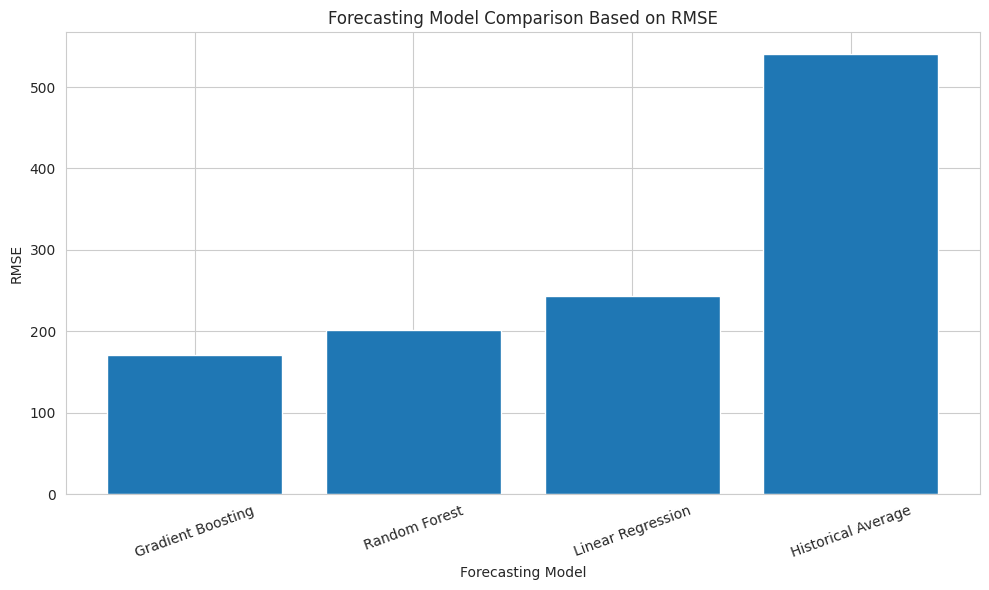

In [187]:

plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title(
    "Forecasting Model Comparison Based on RMSE"
)

plt.xlabel("Forecasting Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "model_comparison_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [188]:

comparison_df = pd.DataFrame({
    "Datetime": test["hour_timestamp"].values,
    "Actual_Demand": y_test.values,
    "Predicted_Demand": best_predictions
})

comparison_df["Prediction_Error"] = (
    comparison_df["Actual_Demand"]
    - comparison_df["Predicted_Demand"]
)

comparison_df["Absolute_Error"] = (
    comparison_df["Prediction_Error"].abs()
)

comparison_df[
    "Absolute_Percentage_Error"
] = np.where(
    comparison_df["Actual_Demand"] > 0,

    (
        comparison_df["Absolute_Error"]
        / comparison_df["Actual_Demand"]
    ) * 100,

    np.nan
)

display(
    comparison_df.head(20).round(2)
)

,Datetime,Actual_Demand,Predicted_Demand,Prediction_Error,Absolute_Error,Absolute_Percentage_Error
0,2025-01-01 00:00:00,189.0,112.17,76.83,76.83,40.65
1,2025-01-01 01:00:00,178.0,104.45,73.55,73.55,41.32
2,2025-01-01 02:00:00,175.0,90.06,84.94,84.94,48.54
3,2025-01-01 03:00:00,136.0,81.29,54.71,54.71,40.23
4,2025-01-01 04:00:00,51.0,66.19,-15.19,15.19,29.79
5,2025-01-01 05:00:00,19.0,49.69,-30.69,30.69,161.54
6,2025-01-01 06:00:00,45.0,63.17,-18.17,18.17,40.39
7,2025-01-01 07:00:00,76.0,98.82,-22.82,22.82,30.03
8,2025-01-01 08:00:00,57.0,125.04,-68.04,68.04,119.36
9,2025-01-01 09:00:00,93.0,126.62,-33.62,33.62,36.16


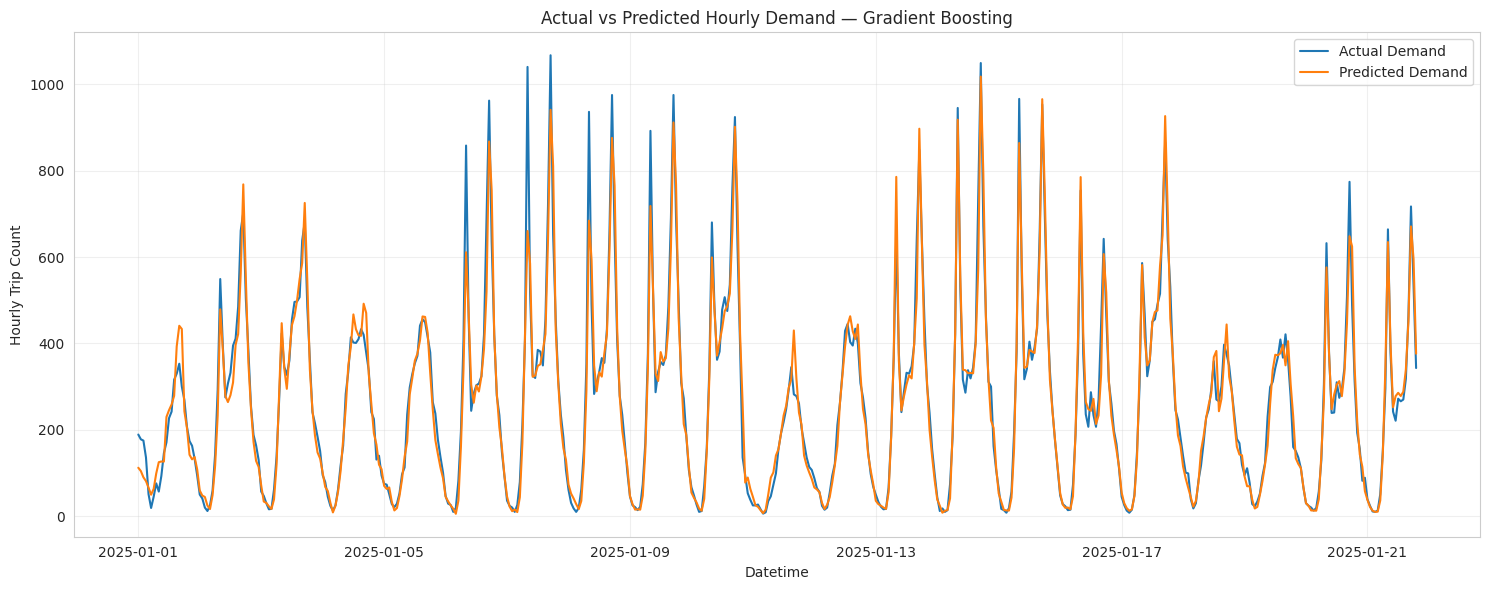

In [189]:

plot_rows = min(
    500,
    len(comparison_df)
)

plt.figure(figsize=(15, 6))

plt.plot(
    comparison_df["Datetime"].iloc[:plot_rows],
    comparison_df["Actual_Demand"].iloc[:plot_rows],
    label="Actual Demand"
)

plt.plot(
    comparison_df["Datetime"].iloc[:plot_rows],
    comparison_df["Predicted_Demand"].iloc[:plot_rows],
    label="Predicted Demand"
)

plt.title(
    f"Actual vs Predicted Hourly Demand — "
    f"{best_model_name}"
)

plt.xlabel("Datetime")
plt.ylabel("Hourly Trip Count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "actual_vs_predicted_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

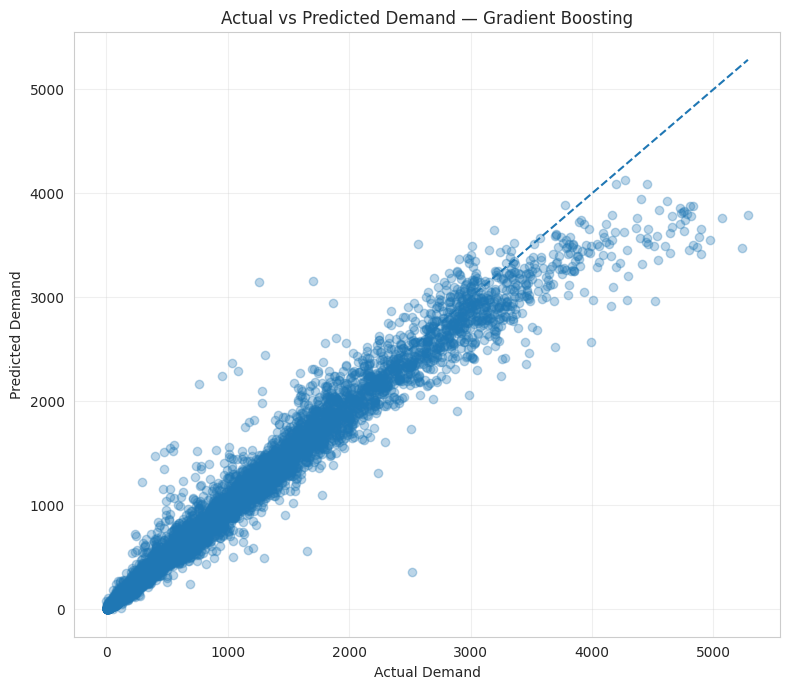

In [190]:

plt.figure(figsize=(8, 7))

plt.scatter(
    comparison_df["Actual_Demand"],
    comparison_df["Predicted_Demand"],
    alpha=0.30
)

minimum_value = min(
    comparison_df["Actual_Demand"].min(),
    comparison_df["Predicted_Demand"].min()
)

maximum_value = max(
    comparison_df["Actual_Demand"].max(),
    comparison_df["Predicted_Demand"].max()
)

plt.plot(
    [
        minimum_value,
        maximum_value
    ],
    [
        minimum_value,
        maximum_value
    ],
    linestyle="--"
)

plt.title(
    f"Actual vs Predicted Demand — "
    f"{best_model_name}"
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "actual_vs_predicted_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

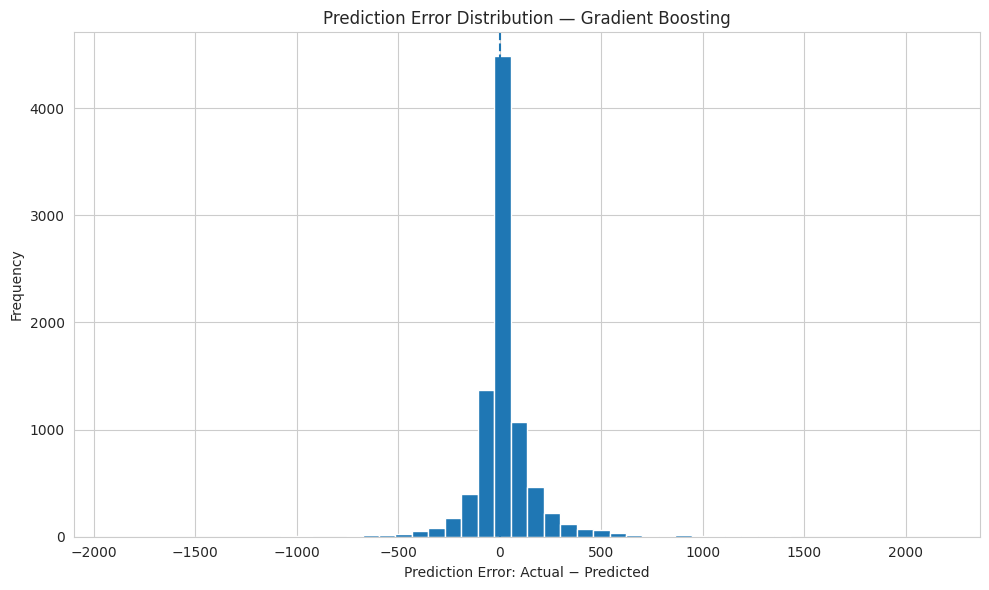

Average prediction error: 21.87


In [191]:

plt.figure(figsize=(10, 6))

plt.hist(
    comparison_df["Prediction_Error"],
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    f"Prediction Error Distribution — "
    f"{best_model_name}"
)

plt.xlabel(
    "Prediction Error: Actual − Predicted"
)

plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    "prediction_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Average prediction error:",
    round(
        comparison_df[
            "Prediction_Error"
        ].mean(),
        2
    )
)

In [192]:

if best_model is not None:

    sample_size = min(
        5000,
        len(X_test)
    )

    X_importance = X_test.iloc[
        :sample_size
    ]

    y_importance = y_test.iloc[
        :sample_size
    ]

    permutation_result = permutation_importance(
        best_model,
        X_importance,
        y_importance,
        n_repeats=5,
        random_state=42,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    feature_importance_df = pd.DataFrame({
        "Feature": features,
        "Importance":
            permutation_result.importances_mean
    })

    feature_importance_df = (
        feature_importance_df
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    display(
        feature_importance_df.head(20).round(4)
    )

else:

    feature_importance_df = pd.DataFrame(
        columns=[
            "Feature",
            "Importance"
        ]
    )

    print(
        "Feature importance is not available "
        "for the historical-average baseline."
    )

,Feature,Importance
0,lag_1,779.8147
1,hour_sin,66.7092
2,lag_24,59.2208
3,lag_168,44.7277
4,hour_cos,41.5471
5,hour,37.1372
6,temperature_c,34.5083
7,relative_humidity,18.5702
8,day_of_week_number,14.6367
9,rolling_std_24,11.2220


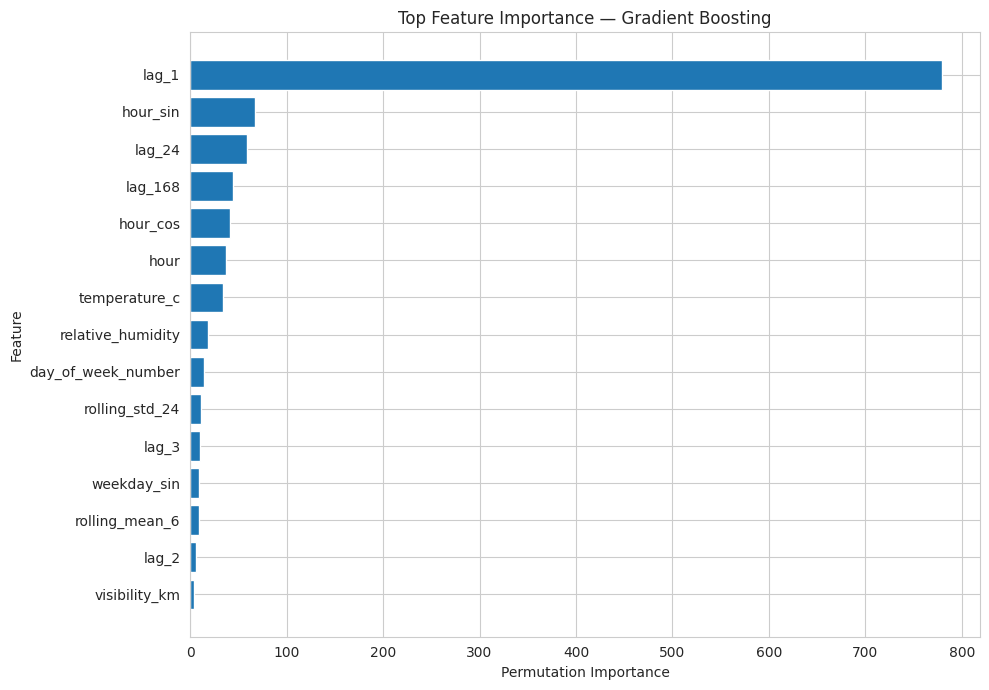

In [193]:
if not feature_importance_df.empty:

    top_features = (
        feature_importance_df
        .head(15)
        .sort_values(
            "Importance",
            ascending=True
        )
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.title(
        f"Top Feature Importance — "
        f"{best_model_name}"
    )

    plt.xlabel("Permutation Importance")
    plt.ylabel("Feature")
    plt.tight_layout()

    plt.savefig(
        "feature_importance.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [194]:

high_demand_threshold = (
    y_train.quantile(0.90)
)

comparison_df["Actual_High_Risk"] = (
    comparison_df["Actual_Demand"]
    >= high_demand_threshold
).astype(int)

comparison_df["Predicted_High_Risk"] = (
    comparison_df["Predicted_Demand"]
    >= high_demand_threshold
).astype(int)

print(
    "High-demand threshold:",
    round(high_demand_threshold, 2)
)

print(
    "Actual high-demand periods:",
    comparison_df["Actual_High_Risk"].sum()
)

print(
    "Predicted high-demand periods:",
    comparison_df["Predicted_High_Risk"].sum()
)

High-demand threshold: 1513.5
Actual high-demand periods: 1857
Predicted high-demand periods: 1833


In [195]:

risk_accuracy = accuracy_score(
    comparison_df["Actual_High_Risk"],
    comparison_df["Predicted_High_Risk"]
)

risk_precision = precision_score(
    comparison_df["Actual_High_Risk"],
    comparison_df["Predicted_High_Risk"],
    zero_division=0
)

risk_recall = recall_score(
    comparison_df["Actual_High_Risk"],
    comparison_df["Predicted_High_Risk"],
    zero_division=0
)

risk_f1 = f1_score(
    comparison_df["Actual_High_Risk"],
    comparison_df["Predicted_High_Risk"],
    zero_division=0
)

high_demand_risk_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        risk_accuracy,
        risk_precision,
        risk_recall,
        risk_f1
    ]
})

display(
    high_demand_risk_metrics.round(4)
)

,Metric,Value
0,Accuracy,0.9751
1,Precision,0.9471
2,Recall,0.9348
3,F1 Score,0.9409


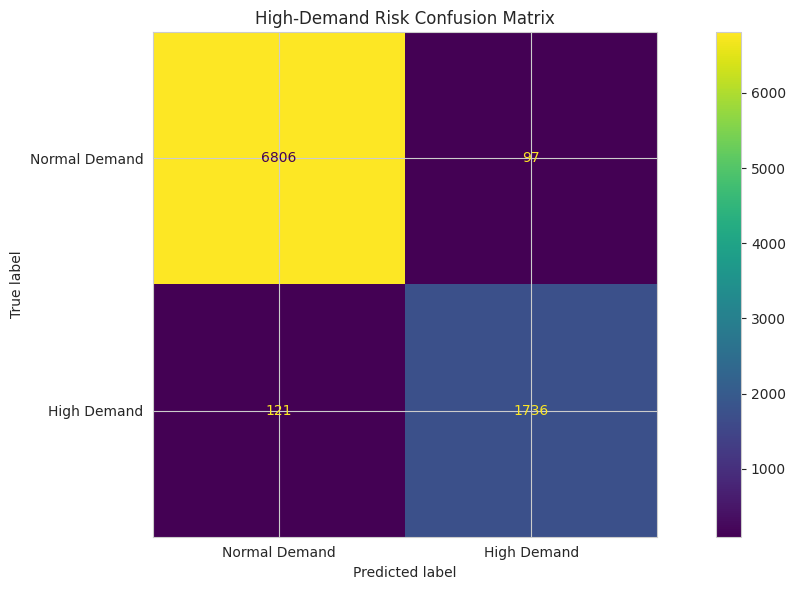

In [196]:

risk_confusion_matrix = confusion_matrix(
    comparison_df["Actual_High_Risk"],
    comparison_df["Predicted_High_Risk"]
)

display_object = ConfusionMatrixDisplay(
    confusion_matrix=risk_confusion_matrix,
    display_labels=[
        "Normal Demand",
        "High Demand"
    ]
)

display_object.plot()

plt.title(
    "High-Demand Risk Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    "high_risk_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [197]:


required_station_columns = [
    "start_time",
    "end_time",
    "start_station_name",
    "end_station_name"
]

missing_station_columns = [
    column
    for column in required_station_columns
    if column not in bike_df.columns
]

if missing_station_columns:

    raise ValueError(
        "Missing bike_df columns: "
        f"{missing_station_columns}"
    )

station_bike_df = bike_df.copy()

station_bike_df["start_time"] = pd.to_datetime(
    station_bike_df["start_time"],
    errors="coerce"
)

station_bike_df["end_time"] = pd.to_datetime(
    station_bike_df["end_time"],
    errors="coerce"
)

station_bike_df = station_bike_df.dropna(
    subset=required_station_columns
).copy()

station_bike_df["start_hour"] = (
    station_bike_df["start_time"]
    .dt.floor("h")
)

station_bike_df["end_hour"] = (
    station_bike_df["end_time"]
    .dt.floor("h")
)

print(
    "Station trip dataset shape:",
    station_bike_df.shape
)

Station trip dataset shape: (326852, 17)


In [198]:


hourly_departures = (
    station_bike_df
    .groupby(
        [
            "start_station_name",
            "start_hour"
        ]
    )
    .size()
    .reset_index(
        name="Departures"
    )
    .rename(
        columns={
            "start_station_name": "Station",
            "start_hour": "Datetime"
        }
    )
)

hourly_arrivals = (
    station_bike_df
    .groupby(
        [
            "end_station_name",
            "end_hour"
        ]
    )
    .size()
    .reset_index(
        name="Arrivals"
    )
    .rename(
        columns={
            "end_station_name": "Station",
            "end_hour": "Datetime"
        }
    )
)

station_hourly_flow = pd.merge(
    hourly_departures,
    hourly_arrivals,
    on=[
        "Station",
        "Datetime"
    ],
    how="outer"
)

station_hourly_flow[
    [
        "Departures",
        "Arrivals"
    ]
] = (
    station_hourly_flow[
        [
            "Departures",
            "Arrivals"
        ]
    ]
    .fillna(0)
    .astype(int)
)

station_hourly_flow = (
    station_hourly_flow
    .sort_values(
        [
            "Station",
            "Datetime"
        ]
    )
    .reset_index(drop=True)
)

display(station_hourly_flow.head())

,Station,Datetime,Departures,Arrivals
0,George St S / The Esplanade,2025-09-16 14:00:00,1,0
1,George St S / The Esplanade,2025-09-16 15:00:00,0,1
2,George St S / The Esplanade,2025-09-21 11:00:00,1,1
3,George St S / The Esplanade,2025-09-23 16:00:00,1,1
4,George St S / The Esplanade,2025-09-25 17:00:00,1,1


In [199]:


station_hourly_flow["Net_Flow"] = (
    station_hourly_flow["Arrivals"]
    - station_hourly_flow["Departures"]
)

station_hourly_flow["Absolute_Imbalance"] = (
    station_hourly_flow["Net_Flow"].abs()
)

station_hourly_flow["Total_Activity"] = (
    station_hourly_flow["Arrivals"]
    + station_hourly_flow["Departures"]
)

display(
    station_hourly_flow.head(20)
)

,Station,Datetime,Departures,Arrivals,Net_Flow,Absolute_Imbalance,Total_Activity
0,George St S / The Esplanade,2025-09-16 14:00:00,1,0,-1,1,1
1,George St S / The Esplanade,2025-09-16 15:00:00,0,1,1,1,1
2,George St S / The Esplanade,2025-09-21 11:00:00,1,1,0,0,2
3,George St S / The Esplanade,2025-09-23 16:00:00,1,1,0,0,2
4,George St S / The Esplanade,2025-09-25 17:00:00,1,1,0,0,2
5,George St S / The Esplanade,2025-09-27 12:00:00,2,2,0,0,4
6,George St S / The Esplanade,2025-10-11 18:00:00,1,1,0,0,2
7,George St S / The Esplanade,2025-10-19 18:00:00,1,1,0,0,2
8,1 Market St,2024-01-11 16:00:00,0,1,1,1,1
9,1 Market St,2024-01-14 10:00:00,1,0,-1,1,1


In [200]:


minimum_activity = 3

active_station_hours = (
    station_hourly_flow[
        station_hourly_flow["Total_Activity"]
        >= minimum_activity
    ]
    .copy()
)

if active_station_hours.empty:

    raise ValueError(
        "No active station-hours were found."
    )

shortage_threshold = (
    active_station_hours["Net_Flow"]
    .quantile(0.05)
)

overflow_threshold = (
    active_station_hours["Net_Flow"]
    .quantile(0.95)
)

print(
    "Minimum station activity:",
    minimum_activity
)

print(
    "Shortage-risk threshold:",
    shortage_threshold
)

print(
    "Overflow-risk threshold:",
    overflow_threshold
)

Minimum station activity: 3
Shortage-risk threshold: -3.0
Overflow-risk threshold: 3.0


In [201]:

def classify_station_risk(row):

    if row["Total_Activity"] < minimum_activity:

        return "Low Activity"

    if row["Net_Flow"] <= shortage_threshold:

        return "Shortage Risk"

    if row["Net_Flow"] >= overflow_threshold:

        return "Overflow Risk"

    return "Balanced"


station_hourly_flow["Risk_Type"] = (
    station_hourly_flow.apply(
        classify_station_risk,
        axis=1
    )
)

station_hourly_flow["Failure_Risk"] = (
    station_hourly_flow["Risk_Type"]
    .isin(
        [
            "Shortage Risk",
            "Overflow Risk"
        ]
    )
    .astype(int)
)

display(
    station_hourly_flow[
        [
            "Station",
            "Datetime",
            "Departures",
            "Arrivals",
            "Net_Flow",
            "Total_Activity",
            "Risk_Type"
        ]
    ].head(25)
)

,Station,Datetime,Departures,Arrivals,Net_Flow,Total_Activity,Risk_Type
0,George St S / The Esplanade,2025-09-16 14:00:00,1,0,-1,1,Low Activity
1,George St S / The Esplanade,2025-09-16 15:00:00,0,1,1,1,Low Activity
2,George St S / The Esplanade,2025-09-21 11:00:00,1,1,0,2,Low Activity
3,George St S / The Esplanade,2025-09-23 16:00:00,1,1,0,2,Low Activity
4,George St S / The Esplanade,2025-09-25 17:00:00,1,1,0,2,Low Activity
5,George St S / The Esplanade,2025-09-27 12:00:00,2,2,0,4,Balanced
6,George St S / The Esplanade,2025-10-11 18:00:00,1,1,0,2,Low Activity
7,George St S / The Esplanade,2025-10-19 18:00:00,1,1,0,2,Low Activity
8,1 Market St,2024-01-11 16:00:00,0,1,1,1,Low Activity
9,1 Market St,2024-01-14 10:00:00,1,0,-1,1,Low Activity


In [202]:


reliability_data = (
    station_hourly_flow[
        station_hourly_flow["Risk_Type"]
        != "Low Activity"
    ]
    .copy()
)

total_station_hours = len(
    reliability_data
)

risk_station_hours = (
    reliability_data["Failure_Risk"]
    .sum()
)

balanced_station_hours = (
    total_station_hours
    - risk_station_hours
)

overall_failure_rate = (
    risk_station_hours
    / total_station_hours
)

overall_reliability = (
    1
    - overall_failure_rate
)

overall_reliability_summary = pd.DataFrame({
    "Metric": [
        "Active Station-Hours",
        "Operational-Risk Hours",
        "Balanced Station-Hours",
        "Operational-Risk Rate",
        "Reliability Proxy"
    ],
    "Value": [
        total_station_hours,
        risk_station_hours,
        balanced_station_hours,
        overall_failure_rate,
        overall_reliability
    ]
})

display(
    overall_reliability_summary
)

print(
    f"Operational-risk rate: "
    f"{overall_failure_rate * 100:.2f}%"
)

print(
    f"Reliability proxy: "
    f"{overall_reliability * 100:.2f}%"
)

,Metric,Value
0,Active Station-Hours,14355.000000
1,Operational-Risk Hours,1676.000000
2,Balanced Station-Hours,12679.000000
3,Operational-Risk Rate,0.116754
4,Reliability Proxy,0.883246


Operational-risk rate: 11.68%
Reliability proxy: 88.32%


In [203]:


station_reliability = (
    reliability_data
    .groupby("Station")
    .agg(
        Observed_Hours=(
            "Datetime",
            "count"
        ),
        Total_Departures=(
            "Departures",
            "sum"
        ),
        Total_Arrivals=(
            "Arrivals",
            "sum"
        ),
        Average_Net_Flow=(
            "Net_Flow",
            "mean"
        ),
        Average_Absolute_Imbalance=(
            "Absolute_Imbalance",
            "mean"
        ),
        Risk_Hours=(
            "Failure_Risk",
            "sum"
        )
    )
    .reset_index()
)

station_reliability["Failure_Rate"] = (
    station_reliability["Risk_Hours"]
    / station_reliability["Observed_Hours"]
)

station_reliability["Reliability_Score"] = (
    1
    - station_reliability["Failure_Rate"]
)


station_reliability_filtered = (
    station_reliability[
        station_reliability["Observed_Hours"]
        >= 100
    ]
    .copy()
)

station_reliability_filtered = (
    station_reliability_filtered
    .sort_values(
        [
            "Failure_Rate",
            "Average_Absolute_Imbalance"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

station_reliability_filtered[
    "Risk_Rank"
] = (
    station_reliability_filtered.index
    + 1
)

display(
    station_reliability_filtered.head(20)
)

,Station,Observed_Hours,Total_Departures,Total_Arrivals,Average_Net_Flow,Average_Absolute_Imbalance,Risk_Hours,Failure_Rate,Reliability_Score,Risk_Rank
0,King St W / Bay St (West Side),309,390,930,1.747573,2.763754,176,0.569579,0.430421,1
1,University Ave / Gerrard St W (East Side),128,215,268,0.414062,1.664062,50,0.390625,0.609375,2
2,Temperance St Station,146,288,301,0.089041,1.335616,35,0.239726,0.760274,3
3,Centre Island Ferry Dock,549,1247,1245,-0.003643,1.530055,111,0.202186,0.797814,4
4,Lake Shore Blvd W / Ontario Dr,109,173,204,0.284404,1.458716,22,0.201835,0.798165,5
5,Union Station,169,268,317,0.289941,1.177515,26,0.153846,0.846154,6
6,York St / Queens Quay W,362,637,652,0.041436,1.151934,51,0.140884,0.859116,7
7,Bay St / College St (East Side),192,356,306,-0.260417,1.125000,27,0.140625,0.859375,8
8,Ward's Island Ferry Dock,178,359,347,-0.067416,1.224719,25,0.140449,0.859551,9
9,Queens Quay / Yonge St,160,276,291,0.093750,1.168750,20,0.125000,0.875000,10


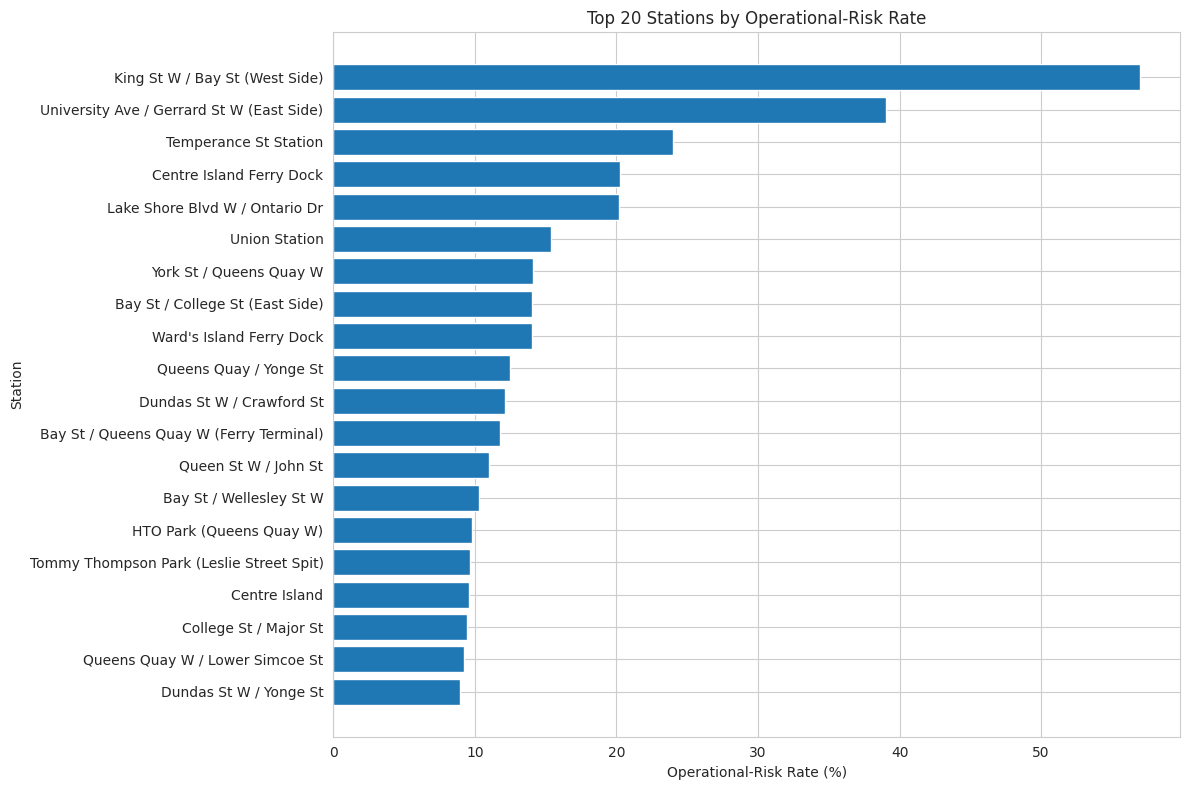

In [204]:


top_risk_stations = (
    station_reliability_filtered
    .head(20)
    .sort_values(
        "Failure_Rate",
        ascending=True
    )
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_risk_stations["Station"],
    top_risk_stations["Failure_Rate"]
    * 100
)

plt.title(
    "Top 20 Stations by Operational-Risk Rate"
)

plt.xlabel("Operational-Risk Rate (%)")
plt.ylabel("Station")
plt.tight_layout()

plt.savefig(
    "top_high_risk_stations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [205]:


reliability_data["Hour"] = (
    reliability_data["Datetime"].dt.hour
)

hourly_risk_summary = (
    reliability_data
    .groupby("Hour")
    .agg(
        Station_Hours=(
            "Failure_Risk",
            "count"
        ),
        Risk_Hours=(
            "Failure_Risk",
            "sum"
        ),
        Average_Imbalance=(
            "Absolute_Imbalance",
            "mean"
        )
    )
    .reset_index()
)

hourly_risk_summary["Failure_Rate"] = (
    hourly_risk_summary["Risk_Hours"]
    / hourly_risk_summary["Station_Hours"]
)

display(hourly_risk_summary)

,Hour,Station_Hours,Risk_Hours,Average_Imbalance,Failure_Rate
0,0,59,3,0.830508,0.050847
1,1,31,0,0.516129,0.000000
2,2,21,1,0.761905,0.047619
3,3,9,0,0.333333,0.000000
4,4,1,0,1.000000,0.000000
5,5,8,0,0.500000,0.000000
6,6,36,2,0.722222,0.055556
7,7,184,35,1.048913,0.190217
8,8,956,212,1.284519,0.221757
9,9,554,129,1.427798,0.232852


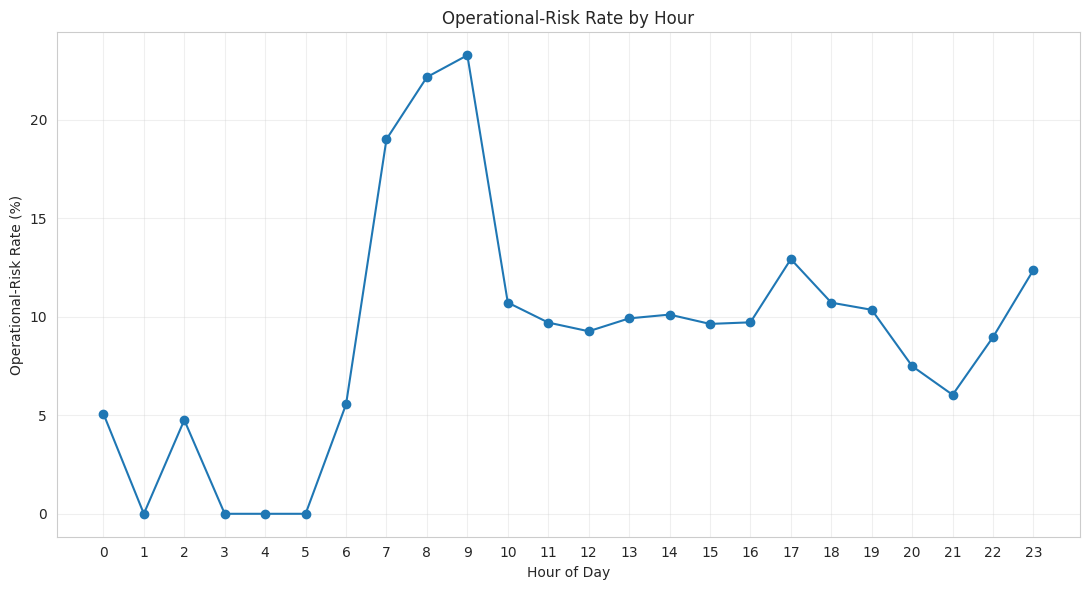

In [206]:
plt.figure(figsize=(11, 6))

plt.plot(
    hourly_risk_summary["Hour"],
    hourly_risk_summary["Failure_Rate"]
    * 100,
    marker="o"
)

plt.title(
    "Operational-Risk Rate by Hour"
)

plt.xlabel("Hour of Day")
plt.ylabel("Operational-Risk Rate (%)")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "risk_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [207]:


reliability_data["Day_Name"] = (
    reliability_data["Datetime"]
    .dt.day_name()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_risk_summary = (
    reliability_data
    .groupby("Day_Name")
    .agg(
        Station_Hours=(
            "Failure_Risk",
            "count"
        ),
        Risk_Hours=(
            "Failure_Risk",
            "sum"
        ),
        Average_Imbalance=(
            "Absolute_Imbalance",
            "mean"
        )
    )
    .reindex(day_order)
    .reset_index()
)

daily_risk_summary["Failure_Rate"] = (
    daily_risk_summary["Risk_Hours"]
    / daily_risk_summary["Station_Hours"]
)

display(daily_risk_summary)

,Day_Name,Station_Hours,Risk_Hours,Average_Imbalance,Failure_Rate
0,Monday,1836,219,1.040305,0.119281
1,Tuesday,2202,299,1.095368,0.135786
2,Wednesday,2263,321,1.110915,0.141847
3,Thursday,2071,264,1.056012,0.127475
4,Friday,1873,164,0.948211,0.087560
5,Saturday,2179,213,1.034878,0.097751
6,Sunday,1931,196,1.013465,0.101502


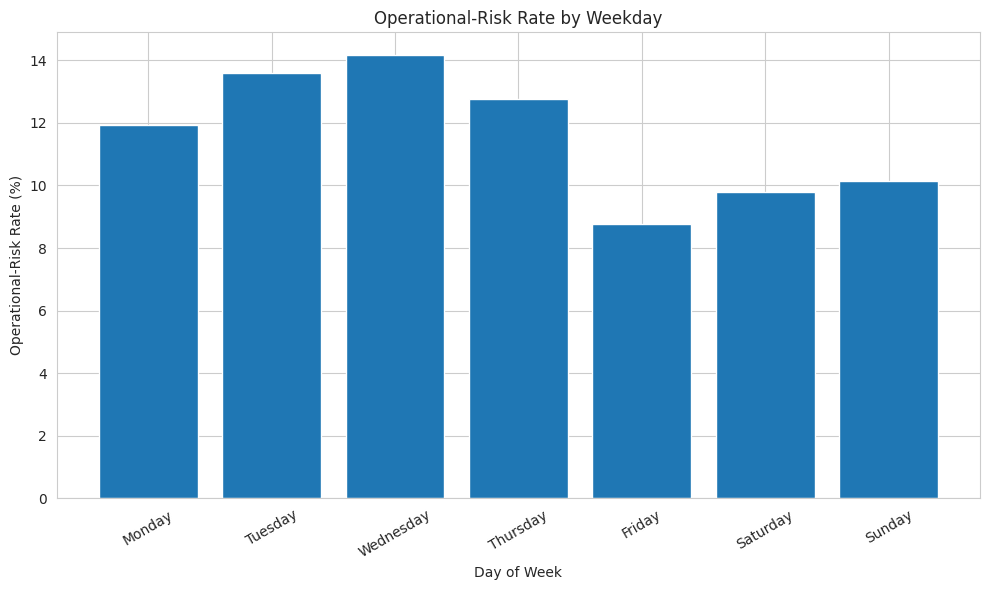

In [208]:
plt.figure(figsize=(10, 6))

plt.bar(
    daily_risk_summary["Day_Name"],
    daily_risk_summary["Failure_Rate"]
    * 100
)

plt.title(
    "Operational-Risk Rate by Weekday"
)

plt.xlabel("Day of Week")
plt.ylabel("Operational-Risk Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    "risk_by_weekday.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [209]:


reliability_data["Month"] = (
    reliability_data["Datetime"].dt.month
)

monthly_risk_summary = (
    reliability_data
    .groupby("Month")
    .agg(
        Station_Hours=(
            "Failure_Risk",
            "count"
        ),
        Risk_Hours=(
            "Failure_Risk",
            "sum"
        ),
        Average_Imbalance=(
            "Absolute_Imbalance",
            "mean"
        )
    )
    .reset_index()
)

monthly_risk_summary["Failure_Rate"] = (
    monthly_risk_summary["Risk_Hours"]
    / monthly_risk_summary["Station_Hours"]
)

display(monthly_risk_summary)

,Month,Station_Hours,Risk_Hours,Average_Imbalance,Failure_Rate
0,1,237,31,1.050633,0.130802
1,2,285,72,1.473684,0.252632
2,3,541,97,1.221811,0.179298
3,4,1079,163,1.170528,0.151066
4,5,2838,515,1.297745,0.181466
5,6,2996,364,1.066422,0.121495
6,7,2925,124,0.796239,0.042393
7,8,2748,171,0.830058,0.062227
8,9,441,71,1.222222,0.160998
9,10,208,37,1.259615,0.177885


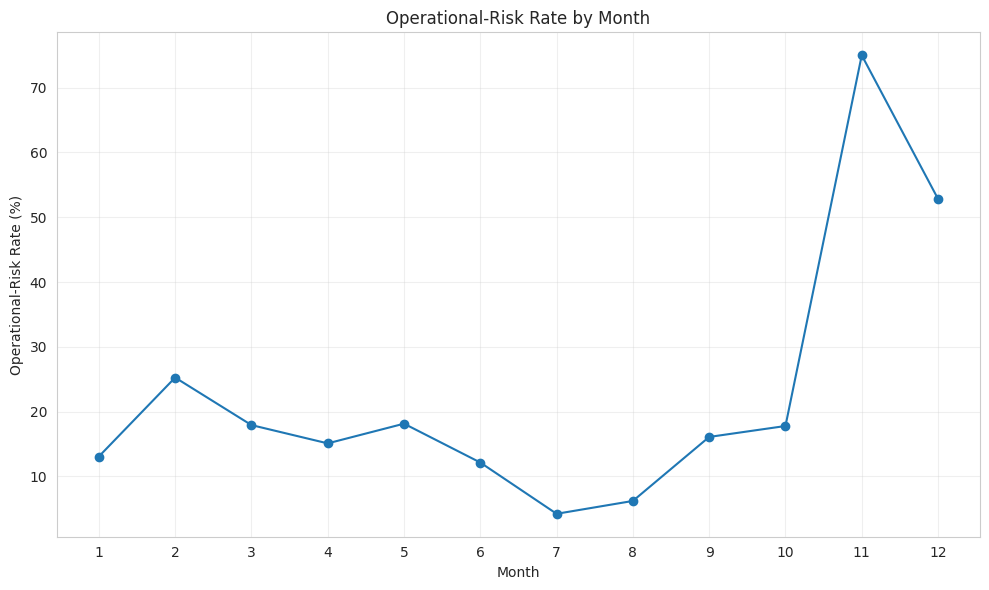

In [210]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_risk_summary["Month"],
    monthly_risk_summary["Failure_Rate"]
    * 100,
    marker="o"
)

plt.title(
    "Operational-Risk Rate by Month"
)

plt.xlabel("Month")
plt.ylabel("Operational-Risk Rate (%)")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "risk_by_month.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [211]:


available_weather_columns = [
    column
    for column in climate_features
    if column in df.columns
]

weather_correlation = (
    df[
        [target]
        + available_weather_columns
    ]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(
        key=abs,
        ascending=False
    )
    .reset_index()
)

weather_correlation.columns = [
    "Weather_Feature",
    "Correlation_With_Demand"
]

display(
    weather_correlation.round(4)
)

,Weather_Feature,Correlation_With_Demand
0,temperature_c,0.5694
1,relative_humidity,-0.4153
2,dew_point_c,0.4048
3,visibility_km,0.1677
4,wind_direction,-0.0575
5,wind_speed_kmh,0.0539
6,station_pressure_kpa,0.0303


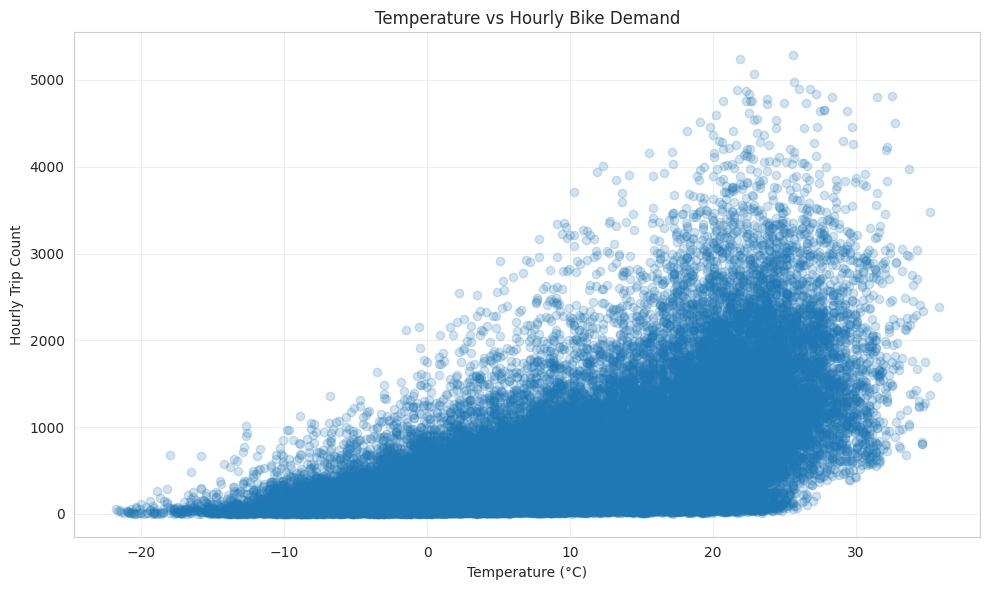

In [212]:


if "temperature_c" in df.columns:

    weather_plot_df = df.dropna(
        subset=[
            "temperature_c",
            target
        ]
    )

    plt.figure(figsize=(10, 6))

    plt.scatter(
        weather_plot_df["temperature_c"],
        weather_plot_df[target],
        alpha=0.20
    )

    plt.title(
        "Temperature vs Hourly Bike Demand"
    )

    plt.xlabel("Temperature (°C)")
    plt.ylabel("Hourly Trip Count")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        "temperature_vs_demand.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [213]:
if "temperature_c" in df.columns:

    df["Temperature_Band"] = pd.cut(
        df["temperature_c"],
        bins=[
            -np.inf,
            0,
            10,
            20,
            30,
            np.inf
        ],
        labels=[
            "Below 0°C",
            "0–10°C",
            "10–20°C",
            "20–30°C",
            "Above 30°C"
        ]
    )

    temperature_demand_summary = (
        df
        .groupby(
            "Temperature_Band",
            observed=False
        )[target]
        .agg(
            Number_of_Hours="count",
            Average_Demand="mean",
            Median_Demand="median",
            Maximum_Demand="max"
        )
        .reset_index()
    )

    display(
        temperature_demand_summary.round(2)
    )

,Temperature_Band,Number_of_Hours,Average_Demand,Median_Demand,Maximum_Demand
0,Below 0°C,8652,192.45,117.0,2150.0
1,0–10°C,12776,398.16,287.0,3349.0
2,10–20°C,12090,742.96,580.0,4519.0
3,20–30°C,9031,1322.41,1203.0,5285.0
4,Above 30°C,387,1702.55,1537.0,4814.0


In [214]:


if "relative_humidity" in df.columns:

    df["Humidity_Band"] = pd.cut(
        df["relative_humidity"],
        bins=[
            0,
            40,
            60,
            80,
            100
        ],
        labels=[
            "Low",
            "Moderate",
            "High",
            "Very High"
        ],
        include_lowest=True
    )

    humidity_demand_summary = (
        df
        .groupby(
            "Humidity_Band",
            observed=False
        )[target]
        .agg(
            Number_of_Hours="count",
            Average_Demand="mean",
            Median_Demand="median",
            Maximum_Demand="max"
        )
        .reset_index()
    )

    display(
        humidity_demand_summary.round(2)
    )

,Humidity_Band,Number_of_Hours,Average_Demand,Median_Demand,Maximum_Demand
0,Low,2524,1279.01,1124.0,4972.0
1,Moderate,10490,1013.58,833.0,5285.0
2,High,17458,581.54,360.0,5240.0
3,Very High,12464,346.82,190.0,3972.0


In [215]:


if "wind_speed_kmh" in df.columns:

    df["Wind_Band"] = pd.cut(
        df["wind_speed_kmh"],
        bins=[
            -np.inf,
            10,
            20,
            30,
            np.inf
        ],
        labels=[
            "Calm",
            "Moderate",
            "Strong",
            "Very Strong"
        ]
    )

    wind_demand_summary = (
        df
        .groupby(
            "Wind_Band",
            observed=False
        )[target]
        .agg(
            Number_of_Hours="count",
            Average_Demand="mean",
            Median_Demand="median",
            Maximum_Demand="max"
        )
        .reset_index()
    )

    display(
        wind_demand_summary.round(2)
    )

,Wind_Band,Number_of_Hours,Average_Demand,Median_Demand,Maximum_Demand
0,Calm,14143,558.51,313.0,4901.0
1,Moderate,17677,724.02,466.0,5285.0
2,Strong,8031,712.55,465.0,4869.0
3,Very Strong,3085,621.08,408.0,5240.0


In [216]:


if "is_event" in df.columns:

    event_demand_summary = (
        df
        .groupby("is_event")
        .agg(
            Number_of_Hours=(
                target,
                "count"
            ),
            Average_Demand=(
                target,
                "mean"
            ),
            Median_Demand=(
                target,
                "median"
            ),
            Maximum_Demand=(
                target,
                "max"
            ),
            Demand_Standard_Deviation=(
                target,
                "std"
            )
        )
        .reset_index()
    )

    event_demand_summary["Day_Type"] = (
        event_demand_summary["is_event"]
        .map({
            0: "Non-Event Day",
            1: "Event Day"
        })
    )

    display(
        event_demand_summary[
            [
                "Day_Type",
                "Number_of_Hours",
                "Average_Demand",
                "Median_Demand",
                "Maximum_Demand",
                "Demand_Standard_Deviation"
            ]
        ].round(2)
    )

,Day_Type,Number_of_Hours,Average_Demand,Median_Demand,Maximum_Demand,Demand_Standard_Deviation
0,Non-Event Day,41208,661.12,409.0,5285.0,716.79
1,Event Day,1728,632.19,326.0,3544.0,699.93


In [217]:


event_percentage_change = np.nan
event_p_value = np.nan

if "is_event" in df.columns:

    normal_day_demand = (
        df.loc[
            df["is_event"] == 0,
            target
        ]
        .dropna()
    )

    event_day_demand = (
        df.loc[
            df["is_event"] == 1,
            target
        ]
        .dropna()
    )

    normal_average = (
        normal_day_demand.mean()
    )

    event_average = (
        event_day_demand.mean()
    )

    if normal_average != 0:

        event_percentage_change = (
            (
                event_average
                - normal_average
            )
            / normal_average
        ) * 100

    print(
        "Average non-event demand:",
        round(normal_average, 2)
    )

    print(
        "Average event-day demand:",
        round(event_average, 2)
    )

    print(
        "Event-day demand change:",
        round(event_percentage_change, 2),
        "%"
    )

    if (
        len(event_day_demand) > 0
        and len(normal_day_demand) > 0
    ):

        event_test_statistic, event_p_value = (
            mannwhitneyu(
                event_day_demand,
                normal_day_demand,
                alternative="two-sided"
            )
        )

        print(
            "Mann–Whitney U statistic:",
            event_test_statistic
        )

        print(
            "P-value:",
            event_p_value
        )

        if event_p_value < 0.05:

            print(
                "The difference between event and "
                "non-event demand is statistically "
                "significant."
            )

        else:

            print(
                "The difference between event and "
                "non-event demand is not statistically "
                "significant."
            )

Average non-event demand: 661.12
Average event-day demand: 632.19
Event-day demand change: -4.38 %
Mann–Whitney U statistic: 34160778.0
P-value: 0.004254671926638291
The difference between event and non-event demand is statistically significant.


In [218]:


def create_rebalancing_action(row):

    if row["Risk_Type"] == "Shortage Risk":

        return (
            "Deliver bikes before the next hour"
        )

    if row["Risk_Type"] == "Overflow Risk":

        return (
            "Remove bikes or increase available "
            "dock capacity"
        )

    if row["Risk_Type"] == "Balanced":

        return "Monitor station"

    return "No immediate action"


station_hourly_flow[
    "Recommended_Action"
] = (
    station_hourly_flow.apply(
        create_rebalancing_action,
        axis=1
    )
)

station_hourly_flow[
    "Estimated_Bikes_To_Move"
] = np.where(
    station_hourly_flow["Failure_Risk"] == 1,

    station_hourly_flow[
        "Absolute_Imbalance"
    ],

    0
)

station_hourly_flow[
    "Rebalancing_Direction"
] = np.select(
    [
        station_hourly_flow["Risk_Type"]
        == "Shortage Risk",

        station_hourly_flow["Risk_Type"]
        == "Overflow Risk"
    ],
    [
        "Deliver bikes to station",
        "Remove bikes from station"
    ],
    default="No movement required"
)

display(
    station_hourly_flow[
        [
            "Station",
            "Datetime",
            "Departures",
            "Arrivals",
            "Net_Flow",
            "Risk_Type",
            "Estimated_Bikes_To_Move",
            "Rebalancing_Direction",
            "Recommended_Action"
        ]
    ].head(30)
)

,Station,Datetime,Departures,Arrivals,Net_Flow,Risk_Type,Estimated_Bikes_To_Move,Rebalancing_Direction,Recommended_Action
0,George St S / The Esplanade,2025-09-16 14:00:00,1,0,-1,Low Activity,0,No movement required,No immediate action
1,George St S / The Esplanade,2025-09-16 15:00:00,0,1,1,Low Activity,0,No movement required,No immediate action
2,George St S / The Esplanade,2025-09-21 11:00:00,1,1,0,Low Activity,0,No movement required,No immediate action
3,George St S / The Esplanade,2025-09-23 16:00:00,1,1,0,Low Activity,0,No movement required,No immediate action
4,George St S / The Esplanade,2025-09-25 17:00:00,1,1,0,Low Activity,0,No movement required,No immediate action
5,George St S / The Esplanade,2025-09-27 12:00:00,2,2,0,Balanced,0,No movement required,Monitor station
6,George St S / The Esplanade,2025-10-11 18:00:00,1,1,0,Low Activity,0,No movement required,No immediate action
7,George St S / The Esplanade,2025-10-19 18:00:00,1,1,0,Low Activity,0,No movement required,No immediate action
8,1 Market St,2024-01-11 16:00:00,0,1,1,Low Activity,0,No movement required,No immediate action
9,1 Market St,2024-01-14 10:00:00,1,0,-1,Low Activity,0,No movement required,No immediate action


In [219]:


station_hourly_flow["Priority_Score"] = (
    station_hourly_flow[
        "Absolute_Imbalance"
    ]
    * np.log1p(
        station_hourly_flow[
            "Total_Activity"
        ]
    )
)

risk_rows = (
    station_hourly_flow[
        station_hourly_flow[
            "Failure_Risk"
        ] == 1
    ]
    .copy()
)

if not risk_rows.empty:

    risk_rows["Priority_Level"] = pd.qcut(
        risk_rows[
            "Priority_Score"
        ].rank(method="first"),
        q=3,
        labels=[
            "Low",
            "Medium",
            "High"
        ]
    )

priority_rebalancing_table = (
    risk_rows
    .sort_values(
        "Priority_Score",
        ascending=False
    )
    [
        [
            "Station",
            "Datetime",
            "Departures",
            "Arrivals",
            "Net_Flow",
            "Risk_Type",
            "Estimated_Bikes_To_Move",
            "Rebalancing_Direction",
            "Priority_Score",
            "Priority_Level"
        ]
    ]
    .reset_index(drop=True)
)

display(
    priority_rebalancing_table.head(25)
)

,Station,Datetime,Departures,Arrivals,Net_Flow,Risk_Type,Estimated_Bikes_To_Move,Rebalancing_Direction,Priority_Score,Priority_Level
0,King St W / Bay St (West Side),2024-05-23 09:00:00,0,11,11,Overflow Risk,11,Remove bikes from station,27.333973,High
1,King St W / Bay St (West Side),2024-05-30 09:00:00,0,11,11,Overflow Risk,11,Remove bikes from station,27.333973,High
2,King St W / Bay St (West Side),2024-04-16 09:00:00,0,11,11,Overflow Risk,11,Remove bikes from station,27.333973,High
3,King St W / Bay St (West Side),2024-06-12 08:00:00,0,11,11,Overflow Risk,11,Remove bikes from station,27.333973,High
4,King St W / Bay St (West Side),2024-05-29 08:00:00,0,9,9,Overflow Risk,9,Remove bikes from station,20.723266,High
5,King St W / Bay St (West Side),2024-05-06 08:00:00,0,8,8,Overflow Risk,8,Remove bikes from station,17.577797,High
6,King St W / Bay St (West Side),2024-03-05 08:00:00,0,8,8,Overflow Risk,8,Remove bikes from station,17.577797,High
7,King St W / Bay St (West Side),2024-05-28 08:00:00,0,7,7,Overflow Risk,7,Remove bikes from station,14.556091,High
8,King St W / Bay St (West Side),2024-03-12 09:00:00,0,7,7,Overflow Risk,7,Remove bikes from station,14.556091,High
9,King St W / Bay St (West Side),2024-05-16 08:00:00,0,7,7,Overflow Risk,7,Remove bikes from station,14.556091,High


In [220]:


reactive_threshold = (
    reliability_data[
        "Absolute_Imbalance"
    ]
    .quantile(0.99)
)

strategy_data = (
    reliability_data.copy()
)

strategy_data["Reactive_Action"] = (
    strategy_data[
        "Absolute_Imbalance"
    ]
    >= reactive_threshold
).astype(int)

strategy_data["Proactive_Action"] = (
    strategy_data[
        "Failure_Risk"
    ]
)

total_risk_hours = (
    strategy_data[
        "Failure_Risk"
    ].sum()
)

reactive_risk_hours_addressed = (
    (
        strategy_data[
            "Reactive_Action"
        ] == 1
    )
    &
    (
        strategy_data[
            "Failure_Risk"
        ] == 1
    )
).sum()

proactive_risk_hours_addressed = (
    (
        strategy_data[
            "Proactive_Action"
        ] == 1
    )
    &
    (
        strategy_data[
            "Failure_Risk"
        ] == 1
    )
).sum()

reactive_coverage = (
    reactive_risk_hours_addressed
    / total_risk_hours
    if total_risk_hours > 0
    else 0
)

proactive_coverage = (
    proactive_risk_hours_addressed
    / total_risk_hours
    if total_risk_hours > 0
    else 0
)

strategy_comparison = pd.DataFrame({
    "Strategy": [
        "Reactive Severe-Imbalance Baseline",
        "Proactive Risk-Based Strategy"
    ],
    "Risk_Hours_Addressed": [
        reactive_risk_hours_addressed,
        proactive_risk_hours_addressed
    ],
    "Total_Risk_Hours": [
        total_risk_hours,
        total_risk_hours
    ],
    "Risk_Coverage_Percentage": [
        reactive_coverage * 100,
        proactive_coverage * 100
    ]
})

display(
    strategy_comparison.round(2)
)

,Strategy,Risk_Hours_Addressed,Total_Risk_Hours,Risk_Coverage_Percentage
0,Reactive Severe-Imbalance Baseline,301,1676,17.96
1,Proactive Risk-Based Strategy,1676,1676,100.00


In [221]:


highest_risk_station = (
    station_reliability_filtered
    .iloc[0]["Station"]
    if not station_reliability_filtered.empty
    else "Not available"
)

highest_risk_hour = (
    hourly_risk_summary
    .sort_values(
        "Failure_Rate",
        ascending=False
    )
    .iloc[0]["Hour"]
)

highest_risk_day = (
    daily_risk_summary
    .dropna(
        subset=["Failure_Rate"]
    )
    .sort_values(
        "Failure_Rate",
        ascending=False
    )
    .iloc[0]["Day_Name"]
)

highest_risk_month = (
    monthly_risk_summary
    .sort_values(
        "Failure_Rate",
        ascending=False
    )
    .iloc[0]["Month"]
)

final_results_summary = pd.DataFrame({
    "Result": [
        "Best Forecasting Model",
        "Best-Model MAE",
        "Best-Model RMSE",
        "Best-Model R²",
        "High-Demand Accuracy",
        "High-Demand Precision",
        "High-Demand Recall",
        "High-Demand F1 Score",
        "Operational-Risk Rate",
        "Reliability Proxy",
        "Highest-Risk Station",
        "Highest-Risk Hour",
        "Highest-Risk Weekday",
        "Highest-Risk Month",
        "Event-Day Demand Change",
        "Event Effect P-Value"
    ],
    "Value": [
        best_model_name,
        round(results.iloc[0]["MAE"], 2),
        round(results.iloc[0]["RMSE"], 2),
        round(results.iloc[0]["R2"], 4),
        round(risk_accuracy, 4),
        round(risk_precision, 4),
        round(risk_recall, 4),
        round(risk_f1, 4),
        f"{overall_failure_rate * 100:.2f}%",
        f"{overall_reliability * 100:.2f}%",
        highest_risk_station,
        int(highest_risk_hour),
        highest_risk_day,
        int(highest_risk_month),
        (
            f"{event_percentage_change:.2f}%"
            if not np.isnan(
                event_percentage_change
            )
            else "Not available"
        ),
        (
            round(event_p_value, 6)
            if not np.isnan(event_p_value)
            else "Not available"
        )
    ]
})

display(final_results_summary)

,Result,Value
0,Best Forecasting Model,Gradient Boosting
1,Best-Model MAE,88.45
2,Best-Model RMSE,170.8
3,Best-Model R²,0.9671
4,High-Demand Accuracy,0.9751
5,High-Demand Precision,0.9471
6,High-Demand Recall,0.9348
7,High-Demand F1 Score,0.9409
8,Operational-Risk Rate,11.68%
9,Reliability Proxy,88.32%


In [222]:


results.to_csv(
    "model_comparison_results.csv",
    index=False
)

comparison_df.to_csv(
    "actual_vs_predicted_results.csv",
    index=False
)

feature_importance_df.to_csv(
    "feature_importance_results.csv",
    index=False
)

high_demand_risk_metrics.to_csv(
    "high_demand_risk_metrics.csv",
    index=False
)

station_hourly_flow.to_csv(
    "station_hourly_reliability_analysis.csv",
    index=False
)

overall_reliability_summary.to_csv(
    "overall_reliability_summary.csv",
    index=False
)

station_reliability_filtered.to_csv(
    "station_reliability_ranking.csv",
    index=False
)

hourly_risk_summary.to_csv(
    "risk_by_hour.csv",
    index=False
)

daily_risk_summary.to_csv(
    "risk_by_weekday.csv",
    index=False
)

monthly_risk_summary.to_csv(
    "risk_by_month.csv",
    index=False
)

weather_correlation.to_csv(
    "weather_demand_correlation.csv",
    index=False
)

priority_rebalancing_table.to_csv(
    "proactive_rebalancing_recommendations.csv",
    index=False
)

strategy_comparison.to_csv(
    "proactive_vs_reactive_comparison.csv",
    index=False
)

final_results_summary.to_csv(
    "final_mrp_results_summary.csv",
    index=False
)

if "event_demand_summary" in globals():

    event_demand_summary.to_csv(
        "event_vs_non_event_demand.csv",
        index=False
    )

print(
    "All MRP result tables saved successfully."
)

All MRP result tables saved successfully.


In [223]:


output_files = [
    "model_comparison_results.csv",
    "actual_vs_predicted_results.csv",
    "feature_importance_results.csv",
    "high_demand_risk_metrics.csv",
    "station_hourly_reliability_analysis.csv",
    "overall_reliability_summary.csv",
    "station_reliability_ranking.csv",
    "risk_by_hour.csv",
    "risk_by_weekday.csv",
    "risk_by_month.csv",
    "weather_demand_correlation.csv",
    "event_vs_non_event_demand.csv",
    "proactive_rebalancing_recommendations.csv",
    "proactive_vs_reactive_comparison.csv",
    "final_mrp_results_summary.csv",
    "model_comparison_bar_chart.png",
    "actual_vs_predicted_demand.png",
    "actual_vs_predicted_scatter.png",
    "prediction_error_distribution.png",
    "feature_importance.png",
    "high_risk_confusion_matrix.png",
    "top_high_risk_stations.png",
    "risk_by_hour.png",
    "risk_by_weekday.png",
    "risk_by_month.png",
    "temperature_vs_demand.png"
]

existing_output_files = [
    file_name
    for file_name in output_files
    if os.path.exists(file_name)
]

zip_file_name = (
    "Toronto_Bike_Share_MRP_Results.zip"
)

with zipfile.ZipFile(
    zip_file_name,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    for file_name in existing_output_files:

        zip_file.write(
            file_name,
            arcname=file_name
        )

print(
    "ZIP file created:",
    zip_file_name
)

print(
    "Number of files included:",
    len(existing_output_files)
)

ZIP file created: Toronto_Bike_Share_MRP_Results.zip
Number of files included: 26


In [224]:


from google.colab import files

files.download(
    "Toronto_Bike_Share_MRP_Results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>